# Solution Part:
* Data Understanding
* Data Exploration
* Data Cleaning
* Data Preparation/Feature Engineering
* Model Building
* Model Evaluation

In [2]:
#Import all the libraries
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [5]:
pd.set_option('display.max_rows', None)

In [6]:
#Read the dataset
cars = pd.read_parquet('Customer Database.parquet')
cars_test = pd.read_excel('Test Customer Data.xlsx')
cars_test_original = cars_test.copy()

In [7]:
cars.shape

(4747051, 36)

In [8]:
cars.head()

,Location_Region,VRLOCATION,VRSALEAMT,VRMILEAGE,Vehicle_year,Trim,Series,Vehicle_cylinders,Vehicle_botcolor,Vehicle_doors,Vehicle_trantype,Vehicle_engine,Vehicle_drive,Vehicle_condition_drivable,Vehicle_condition_overall,BodyClass,DriveType,EngineHP,FuelTypePrimary,EngineConfiguration,EngineModel,GVWR,PlantCountry,BasePrice,IsEV,EVType,MarketSegment,SALEDATE_WeekofYearNumber,SALEDATE_MonthofYearNumber,SALEDATE_Quarter,SALEDATE_Year,Model,Make,VRSALEDATE,VRLIGHTS,Misc_SalesChannel
0,EAST,CHARLESTON,1900,4573,2017,None,4 passenger,1.0,BLU,2.0,A,1.0,R,Y,5.0,Low Speed Vehicle (LSV) / Neighborhood Electri...,None,NaN,None,None,None,"Class 1A: 3,000 lb or less (1,360 kg or less)",UNITED STATES (USA),NaN,0.0,ICE,Other,1,1,4.0,2025,2Five,E-Z-GO DIVISION OF TEXTRON,20250110,R,SIMULCAST
1,WEST,SANANTONIO,4000,12192,1987,None,Integral with body cab,NaN,YEL,NaN,A,0.7,R,Y,4.0,Truck,6x6,NaN,None,V-Shaped,None,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,17,4,NaN,2022,Speciality Vehicle,OSHKOSH,20220426,R,IN LANE
2,WEST,HOUSTON,2900,84304,1984,None,V - Series,8.0,TEA,NaN,I,10.4,R,Y,3.0,Incomplete,4x2,250.0,None,V-Shaped,None,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,32,8,NaN,2022,Speciality Vehicle,OSHKOSH,20220811,R,IN LANE
3,NORTH,CHICAGO,3250,34505,2018,None,None,NaN,WHT,NaN,A,NaN,R,Y,3.0,None,None,NaN,None,None,None,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,20,5,NaN,2021,None,HENDRICKSON,20210519,R,SIMULCAST
4,SOUTH,BIRMINGHAM,10000,52756,2002,None,None,6.0,WHT,NaN,A,5.9,R,Y,4.0,Truck-Tractor,None,NaN,Diesel,In-Line,B Series,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,34,8,NaN,2020,CYT 30,KALMAR INDUSTRIES LLC,20200826,None,IN LANE


In [9]:
# cars.sort_values(by=['Make', 'Model','Trim','Vehicle_year','Vehicle_cylinders'], ascending=[True, True, True, False, True], inplace=True)
# cars[['Make', 'Model', 'VRSALEAMT', 'VRMILEAGE', 'Vehicle_year', 'Trim', 'Vehicle_cylinders']].head(1000)

Data Exploration

In [10]:
def clean_and_fix_temporal(df):
    df = df.copy()

    # --- sale_date (approx from Year+Month if you have them) ---
    # If you also have day, use it. Otherwise pivot to middle-of-month.
    df["SALEDATE_Year"] = pd.to_numeric(df["SALEDATE_Year"], errors="coerce")
    df["SALEDATE_MonthofYearNumber"] = pd.to_numeric(df["SALEDATE_MonthofYearNumber"], errors="coerce").fillna(6)
    df["sale_date"] = pd.to_datetime(df["VRSALEDATE"].astype(str),format="%Y%m%d", errors="coerce")    
    df['IsEV'] = pd.to_numeric(df["IsEV"])


    # --- Vehicle condition grade: extract number safely ---
    # Works for "Grade 3.5", "3.5", 0.0, etc.
    if "Vehicle_condition_overall" in df.columns:
        vc = df["Vehicle_condition_overall"].astype(str).str.extract(r'(\d+(\.\d+)?)')[0]
        df["Vehicle_condition_overall"] = pd.to_numeric(vc, errors="coerce")

    # --- Numeric coercions you rely on downstream ---
    num_cols = [
        'VRMILEAGE','Vehicle_year','Vehicle_cylinders','Vehicle_doors',
        'Vehicle_engine','Vehicle_condition_overall','EngineHP','BasePrice',
        'SALEDATE_WeekofYearNumber','SALEDATE_MonthofYearNumber','SALEDATE_Quarter',
        'SALEDATE_Year','vehicle_age','mileage_per_year','log_mileage','log_age',
        'drivable_flag','GVWR_class'
    ]
    for c in num_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    # --- clamp & age at sale ---
    df["Vehicle_year"] = df["Vehicle_year"].clip(1900, 2100)
    df["vehicle_age"] = (df["SALEDATE_Year"] - df["Vehicle_year"]).clip(lower=0)

    # --- mileage hygiene ---
    # cap ridiculous mileage and fix negatives
    df["VRMILEAGE"] = df["VRMILEAGE"].clip(lower=0, upper=df["VRMILEAGE"].quantile(0.9995))

    # --- safe ratios/logs ---
    age_safe = df["vehicle_age"].replace(0, 0.5)
    df["mileage_per_year"] = df["VRMILEAGE"] / age_safe
    df["log_mileage"] = np.log1p(df["VRMILEAGE"])
    df["log_age"] = np.log1p(df["vehicle_age"])

    # --- drivable ---
    df["drivable_flag"] = (df["Vehicle_condition_drivable"] == "Y").astype(np.int8)

    # --- GVWR numeric class extraction (keeps signal, shrinks OHE) ---
    # "Class 1: 6,000 lb..." -> 1
    if "GVWR" in df.columns:
        df["GVWR_class"] = (
            df["GVWR"].astype(str).str.extract(r'Class\s*(\d+)')[0].astype(float)
        )

    # downcast numerics
    for c in df.select_dtypes(include=[np.number]).columns:
        df[c] = pd.to_numeric(df[c], downcast="float")

    return df

In [11]:
cars = clean_and_fix_temporal(cars)
cars_test = clean_and_fix_temporal(cars_test)

In [12]:
# define grouping columns
group_cols = ["Vehicle_year", "Make", "BodyClass"]
price_col = "VRSALEAMT"      # change if your price column name is different
mileage_col = "VRMILEAGE"

# group statistics
grp = cars.groupby(group_cols)

cars["avg_price"] = grp[price_col].transform("mean")
cars["std_price"] = grp[price_col].transform("std")

cars["avg_mileage"] = grp[mileage_col].transform("mean")
cars["std_mileage"] = grp[mileage_col].transform("std")

# group size
cars["group_size"] = grp[price_col].transform("size")

# deviations
cars["price_dev"] = cars[price_col] - cars["avg_price"]
cars["mileage_dev"] = cars[mileage_col] - cars["avg_mileage"]

# z-scores (safe division)
cars["price_z"] = cars["price_dev"] / cars["std_price"]
cars["mileage_z"] = cars["mileage_dev"] / cars["std_mileage"]

# outlier rule
cars["is_outlier"] = (
    (cars["group_size"] >= 5) &
    (cars["price_z"].abs() > 2.6) &
    (cars["mileage_z"].abs() > 2.6)
)

# print stats before removing
print("Original rows:", len(cars))
print("Outliers removed:", cars["is_outlier"].sum())

# remove outliers
cars = cars.loc[~cars["is_outlier"]].copy()

print("Remaining rows:", len(cars))

# drop helper columns (recommended)
cars.drop(columns=[
    "avg_price","std_price",
    "avg_mileage","std_mileage",
    "group_size","price_dev",
    "mileage_dev","price_z",
    "mileage_z","is_outlier"
], inplace=True)

Original rows: 4747051
Outliers removed: 1226
Remaining rows: 4745825


In [13]:
cars.dtypes

Location_Region                       object
VRLOCATION                            object
VRSALEAMT                            float32
VRMILEAGE                            float64
Vehicle_year                         float32
Trim                                  object
Series                                object
Vehicle_cylinders                    float32
Vehicle_botcolor                      object
Vehicle_doors                        float32
Vehicle_trantype                      object
Vehicle_engine                       float32
Vehicle_drive                         object
Vehicle_condition_drivable            object
Vehicle_condition_overall            float32
BodyClass                             object
DriveType                             object
EngineHP                             float32
FuelTypePrimary                       object
EngineConfiguration                   object
EngineModel                           object
GVWR                                  object
PlantCount

In [14]:
cars.head()

,Location_Region,VRLOCATION,VRSALEAMT,VRMILEAGE,Vehicle_year,Trim,Series,Vehicle_cylinders,Vehicle_botcolor,Vehicle_doors,Vehicle_trantype,Vehicle_engine,Vehicle_drive,Vehicle_condition_drivable,Vehicle_condition_overall,BodyClass,DriveType,EngineHP,FuelTypePrimary,EngineConfiguration,EngineModel,GVWR,PlantCountry,BasePrice,IsEV,EVType,MarketSegment,SALEDATE_WeekofYearNumber,SALEDATE_MonthofYearNumber,SALEDATE_Quarter,SALEDATE_Year,Model,Make,VRSALEDATE,VRLIGHTS,Misc_SalesChannel,sale_date,vehicle_age,mileage_per_year,log_mileage,log_age,drivable_flag,GVWR_class
0,EAST,CHARLESTON,1900.0,4573.0,2017.0,None,4 passenger,1.0,BLU,2.0,A,1.0,R,Y,5.0,Low Speed Vehicle (LSV) / Neighborhood Electri...,None,NaN,None,None,None,"Class 1A: 3,000 lb or less (1,360 kg or less)",UNITED STATES (USA),NaN,0.0,ICE,Other,1.0,1.0,4.0,2025.0,2Five,E-Z-GO DIVISION OF TEXTRON,20250110,R,SIMULCAST,2025-01-10,8.0,571.625000,8.428144,2.197225,1,1.0
1,WEST,SANANTONIO,4000.0,12192.0,1987.0,None,Integral with body cab,NaN,YEL,NaN,A,0.7,R,Y,4.0,Truck,6x6,NaN,None,V-Shaped,None,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,17.0,4.0,NaN,2022.0,Speciality Vehicle,OSHKOSH,20220426,R,IN LANE,2022-04-26,35.0,348.342857,9.408617,3.583519,1,8.0
2,WEST,HOUSTON,2900.0,84304.0,1984.0,None,V - Series,8.0,TEA,NaN,I,10.4,R,Y,3.0,Incomplete,4x2,250.0,None,V-Shaped,None,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,32.0,8.0,NaN,2022.0,Speciality Vehicle,OSHKOSH,20220811,R,IN LANE,2022-08-11,38.0,2218.526316,11.342196,3.663562,1,8.0
3,NORTH,CHICAGO,3250.0,34505.0,2018.0,None,None,NaN,WHT,NaN,A,NaN,R,Y,3.0,None,None,NaN,None,None,None,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,20.0,5.0,NaN,2021.0,None,HENDRICKSON,20210519,R,SIMULCAST,2021-05-19,3.0,11501.666667,10.448889,1.386294,1,8.0
4,SOUTH,BIRMINGHAM,10000.0,52756.0,2002.0,None,None,6.0,WHT,NaN,A,5.9,R,Y,4.0,Truck-Tractor,None,NaN,Diesel,In-Line,B Series,"Class 8: 33,001 lb and above (14,969 kg and ab...",UNITED STATES (USA),NaN,0.0,ICE,HD Truck,34.0,8.0,NaN,2020.0,CYT 30,KALMAR INDUSTRIES LLC,20200826,None,IN LANE,2020-08-26,18.0,2930.888889,10.873452,2.944439,1,8.0


In [15]:
cars_numeric = cars.select_dtypes(include=[np.number])

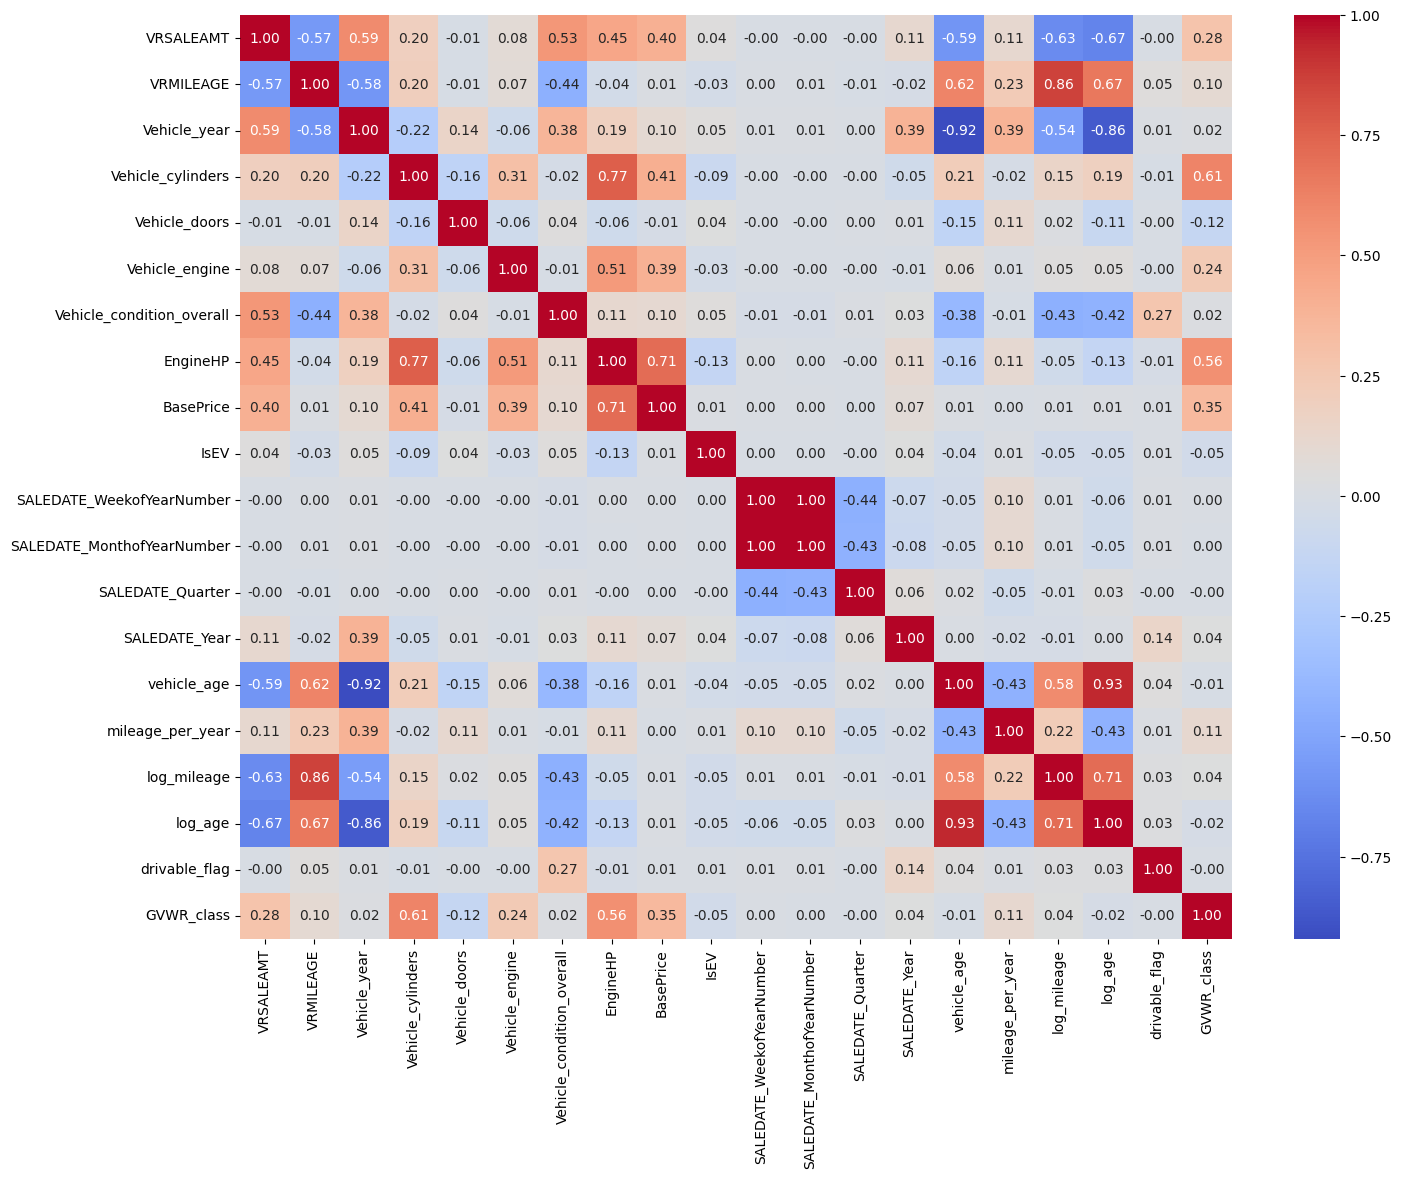

In [16]:
plt.figure(figsize=(16, 12))
sns.heatmap(cars_numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [17]:
#Correlation plot
cor = cars_numeric.corr()
cor

,VRSALEAMT,VRMILEAGE,Vehicle_year,Vehicle_cylinders,Vehicle_doors,Vehicle_engine,Vehicle_condition_overall,EngineHP,BasePrice,IsEV,SALEDATE_WeekofYearNumber,SALEDATE_MonthofYearNumber,SALEDATE_Quarter,SALEDATE_Year,vehicle_age,mileage_per_year,log_mileage,log_age,drivable_flag,GVWR_class
VRSALEAMT,1.000000,-0.567889,0.586671,0.195686,-0.011644,0.081429,0.531203,0.453081,0.404189,0.042096,-0.002504,-0.004651,-0.003229,0.113919,-0.587995,0.106916,-0.630879,-0.667410,-0.000242,0.283284
VRMILEAGE,-0.567889,1.000000,-0.576343,0.201841,-0.007419,0.069584,-0.440365,-0.036185,0.010407,-0.030574,0.004835,0.005007,-0.007579,-0.019450,0.616649,0.227391,0.858793,0.665089,0.049075,0.098535
Vehicle_year,0.586671,-0.576343,1.000000,-0.216815,0.144668,-0.062700,0.376800,0.185298,0.097068,0.049274,0.013581,0.010171,0.004597,0.386341,-0.921311,0.390088,-0.542860,-0.860766,0.014231,0.021227
Vehicle_cylinders,0.195686,0.201841,-0.216815,1.000000,-0.160225,0.307822,-0.021213,0.766255,0.409911,-0.091906,-0.003131,-0.002894,-0.003669,-0.053919,0.212226,-0.017570,0.150784,0.187172,-0.006296,0.612945
Vehicle_doors,-0.011644,-0.007419,0.144668,-0.160225,1.000000,-0.061486,0.042587,-0.064007,-0.014676,0.036674,-0.001115,-0.000898,0.003082,0.010124,-0.152587,0.111864,0.021478,-0.109433,-0.002566,-0.120370
Vehicle_engine,0.081429,0.069584,-0.062700,0.307822,-0.061486,1.000000,-0.005737,0.512178,0.392862,-0.032614,-0.000803,-0.000868,-0.001998,-0.012632,0.062626,0.007530,0.045750,0.053987,-0.002229,0.238874
Vehicle_condition_overall,0.531203,-0.440365,0.376800,-0.021213,0.042587,-0.005737,1.000000,0.107885,0.100936,0.049405,-0.013560,-0.013698,0.011128,0.032629,-0.384047,-0.008500,-0.434534,-0.419579,0.266459,0.023827
EngineHP,0.453081,-0.036185,0.185298,0.766255,-0.064007,0.512178,0.107885,1.000000,0.709472,-0.128867,0.001852,0.000544,-0.002496,0.105965,-0.158853,0.105817,-0.050745,-0.127556,-0.014745,0.559398
BasePrice,0.404189,0.010407,0.097068,0.409911,-0.014676,0.392862,0.100936,0.709472,1.000000,0.013890,0.004347,0.003519,0.000157,0.072019,0.011264,0.001528,0.008007,0.014191,0.005175,0.350958
IsEV,0.042096,-0.030574,0.049274,-0.091906,0.036674,-0.032614,0.049405,-0.128867,0.013890,1.000000,0.000707,0.000703,-0.000377,0.035232,-0.038558,0.010434,-0.050210,-0.047494,0.009304,-0.045905


In [18]:
cars.isnull().sum()

Location_Region                     0
VRLOCATION                          0
VRSALEAMT                           0
VRMILEAGE                           0
Vehicle_year                        0
Trim                          1479529
Series                        2911146
Vehicle_cylinders               30588
Vehicle_botcolor               210456
Vehicle_doors                   41719
Vehicle_trantype               168544
Vehicle_engine                  10044
Vehicle_drive                    1397
Vehicle_condition_drivable          0
Vehicle_condition_overall     2313809
BodyClass                         415
DriveType                     1251841
EngineHP                      2510732
FuelTypePrimary                135201
EngineConfiguration           1766216
EngineModel                   2097901
GVWR                            11929
PlantCountry                     2813
BasePrice                     4135619
IsEV                                0
EVType                              0
MarketSegmen

Data Preparation

In [19]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute   import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error

In [20]:
categorical_cols = cars.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical:", categorical_cols)

Categorical: ['Location_Region', 'VRLOCATION', 'Trim', 'Series', 'Vehicle_botcolor', 'Vehicle_trantype', 'Vehicle_drive', 'Vehicle_condition_drivable', 'BodyClass', 'DriveType', 'FuelTypePrimary', 'EngineConfiguration', 'EngineModel', 'GVWR', 'PlantCountry', 'EVType', 'MarketSegment', 'Model', 'Make', 'VRSALEDATE', 'VRLIGHTS', 'Misc_SalesChannel']


In [21]:
# remove engine from your list of categoricals...
categorical_feats = [
    'Location_Region', 'VRLOCATION', 'Trim', 'Series', 'Vehicle_botcolor', 'Vehicle_trantype', 'Vehicle_drive', 
    'Vehicle_condition_drivable', 'BodyClass', 'DriveType', 'FuelTypePrimary', 'EngineConfiguration', 'EngineModel', 
    'GVWR', 'PlantCountry', 'IsEV', 'EVType', 'MarketSegment', 'Model', 'Make','VRLIGHTS','Misc_SalesChannel'
]
# …and add it into numeric_feats
numeric_feats = [
    'VRMILEAGE','Vehicle_year','Vehicle_cylinders','Vehicle_doors','Vehicle_engine',
    'Vehicle_condition_overall','EngineHP','BasePrice','SALEDATE_WeekofYearNumber','SALEDATE_MonthofYearNumber',
    'SALEDATE_Quarter','SALEDATE_Year','vehicle_age','mileage_per_year','log_mileage','log_age',
    'drivable_flag','GVWR_class'
]


In [22]:
from scipy.stats import skew
skewness = skew(cars['Vehicle_condition_overall'].dropna())
print("Skewness:", skewness)

Skewness: -0.2792711555957794


In [23]:
X_external = cars_test[numeric_feats + categorical_feats]

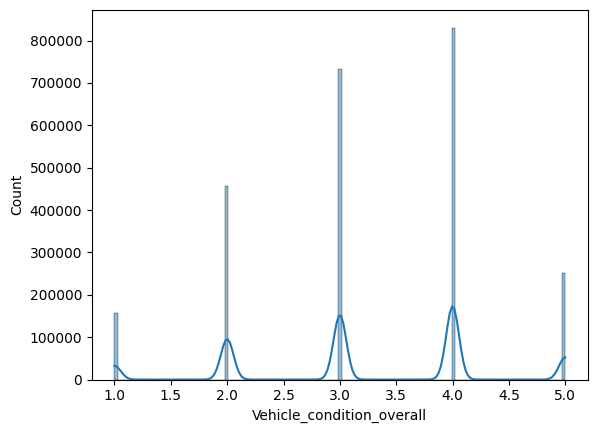

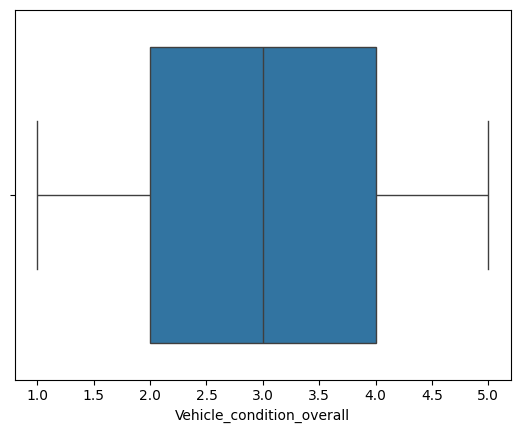

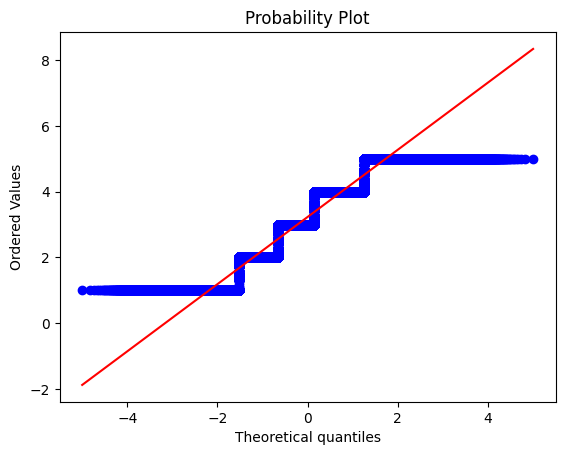

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

sns.histplot(cars['Vehicle_condition_overall'], kde=True)
plt.show()

sns.boxplot(x=cars['Vehicle_condition_overall'])
plt.show()

stats.probplot(cars['Vehicle_condition_overall'].dropna(), dist="norm", plot=plt)
plt.show()

In [25]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scale',   StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown', add_indicator=True)),
    ('ohe',      OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_feats),
    ('cat', cat_pipe, categorical_feats),
], remainder='drop', sparse_threshold=1.0)

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

In [27]:
# ensure sale_date exists and is datetime
assert "sale_date" in cars.columns, "sale_date missing—did you run clean_and_fix_temporal()?"
assert np.issubdtype(cars["sale_date"].dtype, np.datetime64), "sale_date must be datetime"

# Sort & split (as you already do)
cars = cars.dropna(subset=["sale_date"]).sort_values("sale_date")
q90 = cars["sale_date"].quantile(0.90)
q95 = cars["sale_date"].quantile(0.95)

train_mask = cars["sale_date"] < q90
valid_mask = (cars["sale_date"] >= q90) & (cars["sale_date"] < q95)
test_mask  = cars["sale_date"] >= q95

# Build X/y WITHOUT sale_date
X_train = cars.loc[train_mask, numeric_feats + categorical_feats]
y_train = cars.loc[train_mask, "VRSALEAMT"]
X_test  = cars.loc[test_mask,  numeric_feats + categorical_feats]
y_test  = cars.loc[test_mask,  "VRSALEAMT"]

# ✅ Print date ranges from the source df, not from X_* (sale_date isn't a feature)
print("Train range:", cars.loc[train_mask, "sale_date"].min(), "→", cars.loc[train_mask, "sale_date"].max())
print("Test range :", cars.loc[test_mask,  "sale_date"].min(),  "→", cars.loc[test_mask,  "sale_date"].max())
print("Train size :", len(X_train))
print("Test size  :", len(X_test))

Train range: 2019-01-02 00:00:00 → 2025-07-28 00:00:00
Test range : 2025-11-13 00:00:00 → 2026-03-13 00:00:00
Train size : 4268893
Test size  : 240652


In [28]:
# 4. Helper to build a full pipeline + extract coef names
def make_model_pipeline(model, poly=False):
    steps = []
    if poly:
        # expand numeric features to polynomial degree 2
        steps.append(('poly', PolynomialFeatures(degree=2, include_bias=False)))
        steps.append(('preproc', preprocessor))
        steps.append(('reg', model))
    return Pipeline(steps)

def get_feature_names(pipeline):
    """
    After fitting, get the transformed feature names in order, so you can map back to coefficients.
    Requires sklearn ≥ 1.0 for ColumnTransformer.get_feature_names_out.
    """
    # name from the 'preproc' step
    feat_names = pipeline.named_steps['preproc'].get_feature_names_out()
    if 'poly' in pipeline.named_steps:
        # if polynomial, get names from poly step
        feat_names = pipeline.named_steps['poly'].get_feature_names_out(feat_names)
    return feat_names

In [29]:
from sklearn.compose import TransformedTargetRegressor

def with_log_target(pipeline_or_estimator):
    return TransformedTargetRegressor(
        regressor=pipeline_or_estimator,
        func=np.log1p,      # y' = log(1 + y)
        inverse_func=np.expm1  # y = exp(y') - 1
    )

XGBoost

In [ ]:
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from bayes_opt import BayesianOptimization
from sklearn.metrics import r2_score

In [ ]:
# 1) Choose which categoricals to target-encode (high cardinality)
high_card = ["Model","Trim","Series","EngineModel"]
high_card = [c for c in high_card if c in X_train.columns]

In [ ]:
# 2) Low-card categoricals = original list minus the high-card ones
low_card_cats = [c for c in categorical_feats if c not in high_card]

In [ ]:
# 3) Leakage-safe OOF target encoding helper
from sklearn.model_selection import KFold

def oof_target_encode(train_df, test_df, col, target, n_splits=5, smoothing=50):
    """
    Returns (te_train, te_test) for column `col` using leakage-safe OOF means with smoothing.
    """
    global_mean = train_df[target].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    te_train = pd.Series(np.nan, index=train_df.index, dtype=float)

    for tr_idx, val_idx in kf.split(train_df):
        tr = train_df.iloc[tr_idx]
        stats = tr.groupby(col)[target].agg(['count','mean'])
        stats["te"] = (stats["count"]*stats["mean"] + smoothing*global_mean) / (stats["count"] + smoothing)
        te_train.iloc[val_idx] = train_df.iloc[val_idx][col].map(stats["te"]).fillna(global_mean)

    # Fit on full train to transform test
    stats_full = train_df.groupby(col)[target].agg(['count','mean'])
    stats_full["te"] = (stats_full["count"]*stats_full["mean"] + smoothing*global_mean) / (stats_full["count"] + smoothing)
    te_test = test_df[col].map(stats_full["te"]).fillna(global_mean)

    return te_train.astype('float32'), te_test.astype('float32')

In [ ]:
# 4) Apply OOF TE to train/test AND also prep a transformer for your external set
for col in high_card:
    tr_te, te_te = oof_target_encode(
        train_df=pd.concat([X_train, y_train], axis=1),
        test_df=X_test,
        col=col,
        target="VRSALEAMT"
    )
    X_train[f"te__{col}"] = tr_te.values
    X_test[f"te__{col}"]  = te_te.values

In [ ]:
# 5) Do the same transform for your external data (cars_test / X_external)
#    Use ONLY training data stats to encode external
if 'X_external' in globals():
    # reuse the same function but with train_df from the training split
    train_w_target = pd.concat([X_train.drop(columns=[c for c in X_train.columns if c.startswith("te__")], errors='ignore'),
                                y_train], axis=1)
    for col in high_card:
        tr_te_dummy, te_ext = oof_target_encode(
            train_df=train_w_target.rename(columns={"VRSALEAMT": "VRSALEAMT"}),
            test_df=X_external,
            col=col,
            target="VRSALEAMT"
        )
        X_external[f"te__{col}"] = te_ext.values

In [ ]:
# 6) Update your feature lists:
#    - Drop high-card originals from categorical_feats (OHE won’t touch them)
#    - Add the new TE columns to numeric_feats (they’re numeric now)
categorical_feats = [c for c in categorical_feats if c in X_train.columns and c not in high_card]
te_cols = [f"te__{c}" for c in high_card]
numeric_feats = list(dict.fromkeys(list(numeric_feats) + te_cols))  # de-dup while preserving order

In [ ]:
# 7) Rebuild the preprocessor to OHE ONLY the remaining low-card categoricals
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])  # no scaler

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown', add_indicator=True)),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_feats),
    ('cat', cat_pipe, categorical_feats),
], remainder='drop', sparse_threshold=1.0)

In [ ]:
num_cols = X_train.select_dtypes(include=[np.number]).columns
X_train[num_cols] = X_train[num_cols].astype('float32')
X_test[num_cols]  = X_test[num_cols].astype('float32')
X_external[num_cols]  = X_external[num_cols].astype('float32')

In [ ]:
import optuna
import numpy as np
import os
import scipy.sparse as sp
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

# ===== USER KNOBS =====
N_TRIALS = 100
TIME_BUDGET_SECONDS = None
N_SPLITS = 3
FOLD_SAMPLE_FRAC = 0.5     # tune on ~35% of each fold; set to 1.0 if you can afford it
USE_GPU = False             # True if you have CUDA; uses 'gpu_hist'
LOG_TARGET = True
XGB_THREADS = max(1, os.cpu_count() // 2)
# ======================

def _fmt_params(d):
    out = {}
    for k, v in d.items():
        out[k] = float(f"{v:.5g}") if isinstance(v, float) else v
    return out

def _chronologically_sorted(X, y):
    assert "sale_date" in X.columns, "Need sale_date for time-aware splits."
    order = np.argsort(X["sale_date"].values)
    Xs = X.iloc[order].reset_index(drop=True)
    ys = y.iloc[order].reset_index(drop=True)
    return Xs, ys

# 1) Build a parallel sale-date Series for the training window
#    (use whatever your true train mask came from)
sale_dates_train = cars.loc[train_mask, "sale_date"]

# If your sale_date is not datetime (e.g., integers like 20250101), coerce it:
if not np.issubdtype(sale_dates_train.dtype, np.datetime64):
    # try to convert 'YYYYMMDD' ints/strings to datetime
    sale_dates_train = pd.to_datetime(sale_dates_train.astype(str), format="%Y%m%d", errors="coerce")

# 2) Helper that sorts X/y by an external sale-date Series
def _chronologically_sorted(X, y, sale_dates):
    order = np.argsort(sale_dates.values)   # NaT will go last; fine for CV
    Xs = X.iloc[order].reset_index(drop=True)
    ys = y.iloc[order].reset_index(drop=True)
    return Xs, ys

# 3) Sort once up-front (sale_date is NOT included in model features)
X_train_sorted, y_train_sorted = _chronologically_sorted(X_train, y_train, sale_dates_train)

# Optional: small helper to randomly sample each training fold
def _subset_idx(idx, frac, seed):
    if frac >= 1.0: 
        return idx
    rng = np.random.default_rng(seed)
    take = int(len(idx) * frac)
    return np.array(idx)[rng.choice(len(idx), size=take, replace=False)]

def objective(trial):
    # ---------- Search space tuned for ~4M rows ----------
    params = dict(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="gpu_hist" if USE_GPU else "hist",
        grow_policy="lossguide",
        # use leaves instead of depth; depth ignored when lossguide
        max_depth=0,
        max_leaves=trial.suggest_int("max_leaves", 512, 4096, log=True),
        max_bin=trial.suggest_int("max_bin", 128, 512, log=True),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.12, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 20, 200),
        gamma=trial.suggest_float("gamma", 0.0, 10.0),
        # stronger regularization ranges for big data
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 50.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 300.0, log=True),
        subsample=trial.suggest_float("subsample", 0.7, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        colsample_bynode=trial.suggest_float("colsample_bynode", 0.5, 0.9),
        # threading/verbosity
        nthread=XGB_THREADS,
        verbosity=0,
    )
    num_boost_round = trial.suggest_int("n_estimators", 3000, 12000)  # early stopping will truncate

    tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=7)
    rmse_scores = []

    for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_sorted), start=1):
        # Optionally sample each training fold to save time/RAM
        tr_idx_sub = _subset_idx(tr_idx, FOLD_SAMPLE_FRAC, seed=42 + fold)

        X_tr_raw = X_train_sorted.iloc[tr_idx_sub]
        y_tr_raw = y_train_sorted.iloc[tr_idx_sub]
        X_val_raw = X_train_sorted.iloc[val_idx]
        y_val_raw = y_train_sorted.iloc[val_idx]

        # Fit preprocessor per fold (NO leakage), transform to sparse
        preproc = clone(preprocessor).fit(X_tr_raw, y_tr_raw)
        X_tr = preproc.transform(X_tr_raw)
        X_val = preproc.transform(X_val_raw)

        # Ensure sparse CSR float32; DO NOT densify
        if not sp.issparse(X_tr):
            X_tr = sp.csr_matrix(X_tr)
        if not sp.issparse(X_val):
            X_val = sp.csr_matrix(X_val)
        X_tr = X_tr.astype(np.float32)
        X_val = X_val.astype(np.float32)

        # Log target if desired
        y_tr = np.log1p(y_tr_raw.values).astype(np.float32) if LOG_TARGET else y_tr_raw.values.astype(np.float32)
        y_val = np.log1p(y_val_raw.values).astype(np.float32) if LOG_TARGET else y_val_raw.values.astype(np.float32)

        dtr  = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_val, label=y_val)

        booster = xgb.train(
            params,
            dtrain=dtr,
            num_boost_round=num_boost_round,
            evals=[(dval, "valid")],
            callbacks=[xgb.callback.EarlyStopping(rounds=300, save_best=True)],
            verbose_eval=False
        )

        # Predict (already on the best iteration)
        y_pred = booster.inplace_predict(X_val)
        # Evaluate on original scale
        if LOG_TARGET:
            y_pred_eval = np.expm1(y_pred)
            y_val_eval = np.expm1(y_val)
        else:
            y_pred_eval = y_pred
            y_val_eval = y_val

        rmse = float(np.sqrt(np.mean((y_val_eval - y_pred_eval) ** 2)))
        rmse_scores.append(rmse)

        trial.report(-rmse, step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return -float(np.mean(rmse_scores))  # maximize negative RMSE

# ---- Sampler & pruner ----
sampler = optuna.samplers.TPESampler(
    seed=42, n_startup_trials=10, n_ei_candidates=12, multivariate=True, group=True
)
pruner = optuna.pruners.SuccessiveHalvingPruner(min_resource=1, reduction_factor=3)

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(
    objective,
    n_trials=N_TRIALS if TIME_BUDGET_SECONDS is None else None,
    timeout=TIME_BUDGET_SECONDS,
    n_jobs=1,
    show_progress_bar=True
)

print("\n--- OPTUNA COMPLETE ---")
print(f"Best mean -RMSE: {-study.best_value:.6f}")
print("Best params:")
for k, v in _fmt_params(study.best_params).items():
    print(f"  {k}: {v}")

In [ ]:
xgb_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('xgb', XGBRegressor(
        # fixed hyperparameters from BayesOpt:
        tree_method = 'hist',
        device = 'cpu',
        max_leaves = 606,
        max_bin = 354,
        learning_rate=0.033461,
        subsample=0.89539,
        colsample_bytree=0.65389,
        colsample_bynode = 0.79437,
        gamma=0.057052,
        min_child_weight=29,
        reg_alpha=0.00050038,
        reg_lambda=0.31906,
        # keep the rest as before:
        grow_policy='lossguide',
        objective='reg:squarederror',
        eval_metric='rmse',
        n_estimators=7138,
    ))
])

xgb_pipeline_ttr = with_log_target(xgb_pipeline)

In [ ]:
import joblib
import numpy as np
import pandas as pd

# ============================
# INPUTS YOU ALREADY HAVE
# ============================
numeric_feats = [
    'VRMILEAGE','Vehicle_year','Vehicle_cylinders','Vehicle_doors','Vehicle_engine',
    'Vehicle_condition_overall','EngineHP','BasePrice','SALEDATE_WeekofYearNumber',
    'SALEDATE_MonthofYearNumber','SALEDATE_Quarter','SALEDATE_Year','vehicle_age',
    'mileage_per_year','log_mileage','log_age','drivable_flag','GVWR_class',
    'te__Model','te__Trim','te__Series','te__EngineModel'
]

categorical_feats = [
    'Location_Region','Vehicle_botcolor','Vehicle_trantype','Vehicle_drive','VRLOCATION',
    'Vehicle_condition_drivable','BodyClass','DriveType','FuelTypePrimary',
    'EngineConfiguration','GVWR','PlantCountry','IsEV','EVType','MarketSegment','Make','VRLIGHTS','Misc_SalesChannel'
]

high_card = ['Model', 'Trim', 'Series', 'EngineModel']

TARGET = "VRSALEAMT"
BUNDLE_PATH = "xgb_vehicle_price_bundle.joblib"
SCHEMA_VERSION = 1
TE_SMOOTHING = 50.0

# ============================
# 1) SAFETY: de-dup lists and basic checks
# ============================
numeric_feats      = list(pd.Index(numeric_feats).unique())
categorical_feats  = list(pd.Index(categorical_feats).unique())
high_card          = list(pd.Index(high_card).unique())

# TE columns implied by high_card:
te_cols = [f"te__{c}" for c in high_card]

# Ensure numeric_feats contains all te_cols (and only those you intend)
missing_te_in_numeric = [c for c in te_cols if c not in numeric_feats]
if missing_te_in_numeric:
    raise ValueError(f"numeric_feats is missing TE columns: {missing_te_in_numeric}")

# Raw numeric feats = numeric feats excluding te__*
numeric_feats_raw = [c for c in numeric_feats if not c.startswith("te__")]
numeric_feats_raw = list(pd.Index(numeric_feats_raw).unique())

# ============================
# 2) TE MAPS: fit + apply (hardened)
# ============================
def fit_te_maps(X_train_raw: pd.DataFrame,
                y_train: pd.Series,
                high_card: list,
                smoothing: float = 50.0) -> dict:
    """
    Fit target-encoding maps on TRAIN ONLY with smoothing.
    Stores per-column mapping + global mean.
    """
    te_maps = {}
    y_train = pd.to_numeric(y_train, errors="coerce")
    global_mean = float(np.nanmean(y_train))

    for col in high_card:
        if col not in X_train_raw.columns:
            # If missing, store empty mapping; will default to global mean
            te_maps[col] = {"global_mean": global_mean, "mapping": {}}
            continue

        tmp = pd.DataFrame({"col": X_train_raw[col].astype("object"), "y": y_train}).copy()
        tmp["col"] = tmp["col"].fillna("__MISSING__")
        stats = tmp.groupby("col")["y"].agg(["count", "mean"])

        te = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)
        te_maps[col] = {"global_mean": global_mean, "mapping": te.to_dict()}

    return te_maps


def apply_te_maps(df: pd.DataFrame,
                  te_maps: dict,
                  high_card: list) -> pd.DataFrame:
    """
    Apply TE maps. If col missing or unseen category, falls back to global_mean.
    Produces float32 te__* columns.
    """
    df = df.copy()
    for col in high_card:
        g = float(te_maps[col]["global_mean"])
        m = te_maps[col]["mapping"]

        out_col = f"te__{col}"

        if col not in df.columns:
            df[out_col] = g
        else:
            s = df[col].astype("object").fillna("__MISSING__")
            df[out_col] = s.map(m).fillna(g)

        df[out_col] = pd.to_numeric(df[out_col], errors="coerce").fillna(g).astype("float32")

    return df


def make_xgb_features(df_clean: pd.DataFrame,
                      te_maps: dict,
                      high_card: list,
                      numeric_feats: list,
                      categorical_feats: list) -> pd.DataFrame:
    """
    Construct the exact input frame expected by your ColumnTransformer:
      - Adds te__* columns
      - Returns only numeric_feats + categorical_feats (NO raw high_card categoricals)
      - Coerces numeric to float32
      - Ensures categoricals exist and are object dtype (safe for OHE)
    """
    tmp = apply_te_maps(df_clean, te_maps, high_card)

    # Ensure required columns exist
    needed = list(pd.Index(numeric_feats + categorical_feats).unique())
    missing = [c for c in needed if c not in tmp.columns]
    if missing:
        raise KeyError(f"make_xgb_features: missing required columns: {missing}")

    X = tmp[needed].copy()

    # Numeric coercion
    for c in numeric_feats:
        X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")

    # Categorical coercion (OHE pipeline will impute Unknown anyway)
    for c in categorical_feats:
        X[c] = X[c].astype("object")

    return X

# ============================
# 3) BUILD TRAIN RAW FRAME (FIXES YOUR KeyError)
# ============================
# IMPORTANT: cars DOES NOT contain te__* yet. Use numeric_feats_raw + categorical_feats + high_card
raw_cols_needed = list(pd.Index(numeric_feats_raw + categorical_feats + high_card).unique())

missing_raw = [c for c in raw_cols_needed if c not in cars.columns]
if missing_raw:
    raise KeyError(f"These required raw columns are missing from cars: {missing_raw}")

# y_train_raw should align with the same train_mask index
y_train_raw = cars.loc[train_mask, TARGET].copy()
X_train_raw = cars.loc[train_mask, raw_cols_needed].copy()

# ============================
# 4) FIT TE MAPS ON TRAIN WINDOW ONLY
# ============================
te_maps = fit_te_maps(X_train_raw, y_train_raw, high_card=high_card, smoothing=TE_SMOOTHING)

# ============================
# 5) BUILD MODEL TRAIN MATRIX (HAS te__* NOW)
# ============================
X_train_for_model = make_xgb_features(
    df_clean=X_train_raw,
    te_maps=te_maps,
    high_card=high_card,
    numeric_feats=numeric_feats,            # includes te__*
    categorical_feats=categorical_feats     # low-card only
)

# ============================
# 6) FIT MODEL + SAVE BUNDLE
# ============================
xgb_pipeline_ttr.fit(X_train_for_model, y_train_raw)

bundle = {
    "model": xgb_pipeline_ttr,     # includes preprocessor + XGB + log-target wrapper
    "te_maps": te_maps,
    "high_card": high_card,
    "numeric_feats": numeric_feats,
    "categorical_feats": categorical_feats,
    "schema_version": SCHEMA_VERSION,
}

joblib.dump(bundle, BUNDLE_PATH, compress=0)
print(f"Saved: {BUNDLE_PATH}")

# ============================
# 7) OPTIONAL: QUICK INFERENCE HELPERS (recommended)
# ============================
def load_bundle(path=BUNDLE_PATH):
    b = joblib.load(path)
    required = ["model","te_maps","high_card","numeric_feats","categorical_feats","schema_version"]
    miss = [k for k in required if k not in b]
    if miss:
        raise ValueError(f"Bundle missing keys: {miss}")
    return b

def predict_from_bundle(df_clean: pd.DataFrame, bundle: dict) -> np.ndarray:
    X = make_xgb_features(
        df_clean=df_clean,
        te_maps=bundle["te_maps"],
        high_card=bundle["high_card"],
        numeric_feats=bundle["numeric_feats"],
        categorical_feats=bundle["categorical_feats"]
    )
    return bundle["model"].predict(X)

# Example usage:
# b = load_bundle()
# preds_test = predict_from_bundle(cars.loc[test_mask, raw_cols_needed], b)


Saved: xgb_vehicle_price_bundle.joblib


In [ ]:
def bubblesort(arr):
  qw = 0
  while qw < len(arr):
    for i in range(0,len(arr)-1):
      if arr[i] > arr[i+1]:
        arr[i] , arr[i+1] = arr[i+1] , arr[i]
    
    qw += 1
  return arr

arr = [5,9,1,2,7,3,8,2]
print(bubblesort(arr))

[1, 2, 2, 3, 5, 7, 8, 9]


In [ ]:
# 3. Fit & predict just like before
xgb_pipeline_ttr.fit(X_train, y_train)
xgb_predictions = xgb_pipeline_ttr.predict(X_test)
xgb_predictions_external = xgb_pipeline_ttr.predict(X_external)

In [ ]:
xgb_r2 = r2_score(y_test, xgb_predictions)
xgb_mae = mean_absolute_error(y_test, xgb_predictions)
xgb_mse = mean_squared_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(xgb_mse)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_predictions)

# Display results
print("📊 XGBoost Regression Evaluation Metrics")
print(f"R² Score  : {xgb_r2:.4f}")
print(f"MAE       : {xgb_mae:.2f}")
print(f"MSE       : {xgb_mse:.2f}")
print(f"RMSE      : {xgb_rmse:.2f}")
print(f"MAPE      : {xgb_mape:.2%}")

📊 XGBoost Regression Evaluation Metrics
R² Score  : 0.9448
MAE       : 1499.47
MSE       : 7380706.00
RMSE      : 2716.75
MAPE      : 28.93%


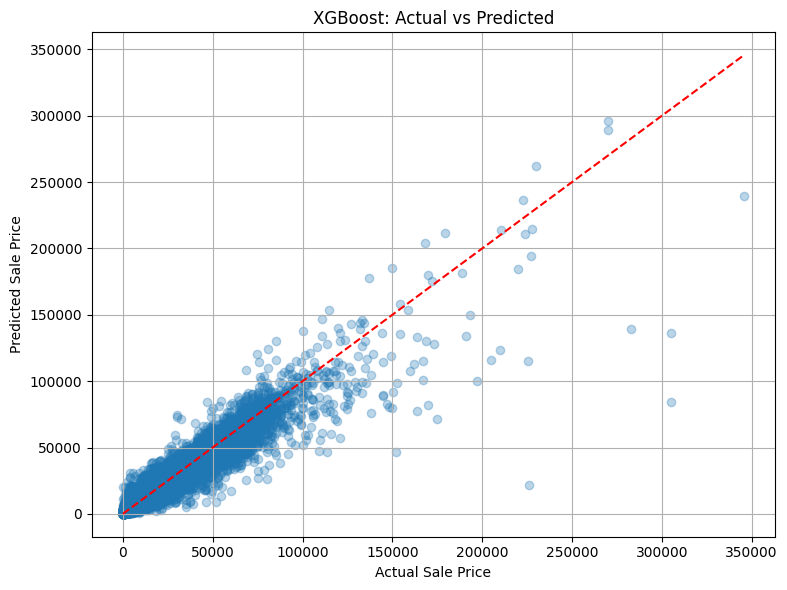

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, xgb_predictions, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('XGBoost: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

CatBoost

In [ ]:
# === CatBoost + Optuna: 2-stage multi-fidelity tuner (ASHA; optional pruning callback) ===
import os, sys, time, numpy as np, pandas as pd
import optuna
from optuna.trial import TrialState
from optuna.pruners import SuccessiveHalvingPruner, HyperbandPruner
from optuna.samplers import TPESampler
from catboost import CatBoostRegressor, Pool, CatBoostError
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

# Try to import the integration callback; fall back if unavailable
try:
    from optuna.integration import CatBoostPruningCallback  # requires optuna-integration[catboost]
    HAS_CB_PRUNE = True
except Exception:
    CatBoostPruningCallback = None
    HAS_CB_PRUNE = False
    print("[INFO] optuna-integration[catboost] not found; continuing without CatBoostPruningCallback "
          "(pruning will occur between folds, not during iterations).", flush=True)

# ================= USER KNOBS =================
TARGET = "VRSALEAMT"
USE_GPU = False
LOG_TARGET = True
SEED = 42
THREADS = max(1, os.cpu_count() // 2)

# Data budgets (multi-fidelity)
STAGE1_MAX_TRAIN_ROWS = 250_000     # tiny/cheap
STAGE2_MAX_TRAIN_ROWS = 800_000     # bigger, still tractable
FOLD_SAMPLE_FRAC_S1 = 0.08          # stronger downsample early
FOLD_SAMPLE_FRAC_S2 = 0.20

# Iteration budgets (multi-fidelity)
STAGE1_ITERS_MIN, STAGE1_ITERS_MAX = 300, 900
STAGE2_ITERS_MIN, STAGE2_ITERS_MAX = 800, 2000

EARLY_STOP_ROUNDS = 100
N_SPLITS = 3
GAP_ROWS = 0

# Trials
STAGE1_TRIALS = 25
STAGE2_TRIALS = 10

# Search space (coarse; we’ll narrow in Stage 2)
DEPTH_RANGE = (6, 10)
L2_RANGE = (3.0, 40.0)
LR_RANGE = (0.02, 0.12)
MDL_RANGE = (512, 4096)
SUBSAMPLE_RANGE = (0.6, 0.95)
RSM_RANGE = (0.7, 0.95)
RAND_STR_RANGE = (0.0, 0.8)

# ============================================================
# Prepare data (assumes df 'cars' with 'sale_date' + TARGET)
assert "sale_date" in cars.columns, "Need 'sale_date' for time-aware CV."
cars_sorted = cars.dropna(subset=["sale_date"]).sort_values("sale_date").reset_index(drop=True)

feature_cols = [c for c in cars_sorted.columns if c not in [TARGET, "sale_date"]]
X_all = cars_sorted[feature_cols].copy()
y_all = cars_sorted[TARGET].astype("float32").copy()
mask = y_all.notna()
X_all = X_all.loc[mask].reset_index(drop=True)
y_all = y_all.loc[mask].reset_index(drop=True)

cat_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_all.select_dtypes(include=[np.number, "boolean"]).columns.tolist()
if cat_cols:
    X_all.loc[:, cat_cols] = X_all.loc[:, cat_cols].fillna("__MISSING__").astype(str)
if num_cols:
    X_all.loc[:, num_cols] = (
        X_all.loc[:, num_cols]
        .replace([np.inf, -np.inf], np.nan)
        .apply(pd.to_numeric, errors="coerce", downcast="float")
    )
cat_idx = [X_all.columns.get_loc(c) for c in cat_cols]

def _subset_df(X, y, frac, seed):
    if frac >= 1.0: return X, y
    idx = X.index.to_series().sample(frac=frac, random_state=seed).index
    return X.loc[idx], y.loc[idx]

def _cap_recent_rows(X, y, cap):
    if cap is None or len(X) <= cap: return X, y
    return X.iloc[-cap:], y.iloc[-cap:]

def _fmt(d):
    out = {}
    for k, v in d.items():
        out[k] = float(f"{v:.5g}") if isinstance(v, float) else v
    return out

def make_objective(max_train_rows, fold_frac, iters_min, iters_max, refine_from=None):
    """
    Build an objective with a given data + iteration budget.
    refine_from: dict of center params to narrow around (from Stage 1 best).
    """
    def near(center, width, lo=None, hi=None):
        lo2, hi2 = center - width, center + width
        if lo is not None: lo2 = max(lo2, lo)
        if hi is not None: hi2 = min(hi2, hi)
        return lo2, hi2

    def objective(trial):
        # ----- Search space -----
        if refine_from is None:
            depth = trial.suggest_int("depth", *DEPTH_RANGE)
            l2 = trial.suggest_float("l2_leaf_reg", *L2_RANGE, log=True)
            lr = trial.suggest_float("learning_rate", *LR_RANGE, log=True)
            mdl = trial.suggest_int("min_data_in_leaf", *MDL_RANGE)
            rsm = trial.suggest_float("rsm", *RSM_RANGE)
            subsample = trial.suggest_float("subsample", *SUBSAMPLE_RANGE)
            rand_str = trial.suggest_float("random_strength", *RAND_STR_RANGE)
        else:
            depth0 = refine_from.get("depth", 8)
            l20 = refine_from.get("l2_leaf_reg", 10.0)
            lr0 = refine_from.get("learning_rate", 0.06)
            mdl0 = refine_from.get("min_data_in_leaf", 1500)
            rsm0 = refine_from.get("rsm", 0.8)
            sub0 = refine_from.get("subsample", 0.8)
            rs0  = refine_from.get("random_strength", 0.2)

            depth = trial.suggest_int("depth", max(6, depth0-1), min(10, depth0+1))
            l2_lo, l2_hi = near(l20, l20*0.7, L2_RANGE[0], L2_RANGE[1])
            l2 = trial.suggest_float("l2_leaf_reg", max(L2_RANGE[0], l2_lo), min(L2_RANGE[1], l2_hi), log=True)
            lr_lo, lr_hi = near(lr0, max(0.005, lr0*0.5), LR_RANGE[0], LR_RANGE[1])
            lr = trial.suggest_float("learning_rate", lr_lo, lr_hi, log=True)
            mdl_lo, mdl_hi = near(mdl0, max(200, mdl0*0.5), MDL_RANGE[0], MDL_RANGE[1])
            mdl = trial.suggest_int("min_data_in_leaf", int(mdl_lo), int(mdl_hi))
            rsm_lo, rsm_hi = near(rsm0, 0.1, RSM_RANGE[0], RSM_RANGE[1])
            rsm = trial.suggest_float("rsm", rsm_lo, rsm_hi)
            sub_lo, sub_hi = near(sub0, 0.1, SUBSAMPLE_RANGE[0], SUBSAMPLE_RANGE[1])
            subsample = trial.suggest_float("subsample", sub_lo, sub_hi)
            rs_lo, rs_hi = near(rs0, 0.2, RAND_STR_RANGE[0], RAND_STR_RANGE[1])
            rand_str = trial.suggest_float("random_strength", rs_lo, rs_hi)

        iterations = trial.suggest_int("iterations", iters_min, iters_max)

        params = dict(
            loss_function="RMSE",
            eval_metric="RMSE",
            depth=depth,
            learning_rate=lr,
            rsm=rsm,
            l2_leaf_reg=l2,
            random_strength=rand_str,
            iterations=iterations,
            od_type="Iter",
            od_wait=EARLY_STOP_ROUNDS,
            use_best_model=True,
            min_data_in_leaf=mdl,
            one_hot_max_size=12,
            border_count=64,
            random_state=SEED,
            thread_count=THREADS,
            verbose=False,     # we may attach pruning callback
            task_type="GPU" if USE_GPU else "CPU",
            bootstrap_type="Bernoulli",
            subsample=subsample,
            allow_writing_files=False,
            boosting_type="Ordered",
        )

        tscv = TimeSeriesSplit(n_splits=N_SPLITS, gap=GAP_ROWS)
        rmses = []

        for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_all), start=1):
            X_tr_raw, y_tr_raw = X_all.iloc[tr_idx], y_all.iloc[tr_idx]
            X_val_raw, y_val_raw = X_all.iloc[val_idx], y_all.iloc[val_idx]

            X_tr, y_tr = _subset_df(X_tr_raw, y_tr_raw, fold_frac, SEED + fold)
            X_tr, y_tr = _cap_recent_rows(X_tr, y_tr, max_train_rows)
            X_val, y_val = X_val_raw, y_val_raw

            y_tr_fit = np.log1p(y_tr.values) if LOG_TARGET else y_tr.values
            y_val_fit = np.log1p(y_val.values) if LOG_TARGET else y_val.values

            train_pool = Pool(X_tr, label=y_tr_fit, cat_features=cat_idx)
            valid_pool = Pool(X_val, label=y_val_fit, cat_features=cat_idx)

            model = CatBoostRegressor(**params)

            # Optional per-iteration pruning if integration is installed
            kwargs = dict(
                verbose=False,
                early_stopping_rounds=EARLY_STOP_ROUNDS,
            )
            if HAS_CB_PRUNE:
                kwargs["callbacks"] = [CatBoostPruningCallback(trial, "RMSE")]

            try:
                model.fit(train_pool, eval_set=valid_pool, **kwargs)
            except (CatBoostError, MemoryError) as e:
                trial.set_user_attr("fit_error", str(e))
                # prune on OOM/alloc to keep study running
                raise optuna.exceptions.TrialPruned()

            # Evaluate on original scale
            y_pred_fit = model.predict(valid_pool)
            y_pred = np.expm1(y_pred_fit) if LOG_TARGET else y_pred_fit
            rmse = float(np.sqrt(mean_squared_error(y_val.values, y_pred)))
            rmses.append(rmse)

            # Report running mean so ASHA/Hyperband can prune between folds
            trial.report(-np.mean(rmses), step=fold)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return -float(np.mean(rmses))

    return objective

def run_stage(n_trials, objective, pruner, study_name="catboost_tune"):
    sampler = TPESampler(seed=SEED, n_startup_trials=8, multivariate=True, group=True)
    study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name=study_name)
    study.optimize(objective, n_trials=n_trials, n_jobs=1, gc_after_trial=True, show_progress_bar=True)
    return study

# ---------------- Stage 1: coarse, cheap (ASHA) ----------------
asha = SuccessiveHalvingPruner(min_resource=1, reduction_factor=3, min_early_stopping_rate=0)
obj_s1 = make_objective(
    max_train_rows=STAGE1_MAX_TRAIN_ROWS,
    fold_frac=FOLD_SAMPLE_FRAC_S1,
    iters_min=STAGE1_ITERS_MIN,
    iters_max=STAGE1_ITERS_MAX,
)
print("=== Stage 1 (coarse, cheap) ===", flush=True)
study1 = run_stage(STAGE1_TRIALS, obj_s1, asha, "catboost_s1")

best_params_s1 = {}
if any(t.state == TrialState.COMPLETE for t in study1.trials):
    best_params_s1 = study1.best_trial.params
    print("Stage 1 best RMSE ~", round(-study1.best_value, 4), flush=True)
    print("Stage 1 best params:", _fmt(best_params_s1), flush=True)
else:
    print("Stage 1 finished with all trials pruned; consider easing budgets.", flush=True)

# ---------------- Stage 2: refine near Stage 1 winner (Hyperband) ----------------
if best_params_s1:
    hb = HyperbandPruner(min_resource=1, max_resource=STAGE2_ITERS_MAX, reduction_factor=3)
    obj_s2 = make_objective(
        max_train_rows=STAGE2_MAX_TRAIN_ROWS,
        fold_frac=FOLD_SAMPLE_FRAC_S2,
        iters_min=STAGE2_ITERS_MIN,
        iters_max=STAGE2_ITERS_MAX,
        refine_from=best_params_s1
    )
    print("\n=== Stage 2 (refine near Stage 1 winner) ===", flush=True)
    study2 = run_stage(STAGE2_TRIALS, obj_s2, hb, "catboost_s2")

    if any(t.state == TrialState.COMPLETE for t in study2.trials):
        print("\n--- FINAL ---", flush=True)
        print("Best CV RMSE:", round(-study2.best_value, 6), flush=True)
        print("Best params:", _fmt(study2.best_params), flush=True)
    else:
        print("Stage 2 had no completed trials; fall back to Stage 1 winner.", flush=True)
else:
    print("\nNo Stage 1 winner; try relaxing budgets (raise STAGE1_MAX_TRAIN_ROWS, FOLD_SAMPLE_FRAC_S1, "
          "or widen iteration ranges).", flush=True)

In [ ]:
from catboost import CatBoostRegressor
catboost_model = CatBoostRegressor(
    iterations= 1793,
    learning_rate= 0.09912556385159192,
    depth= int(9.0),
    rsm= 0.9496437290782105,
    l2_leaf_reg= 5.263059838941717,
    random_strength = 0.584956977885945,
    min_data_in_leaf = 4071,
    subsample = 0.8892185553646252,
    bootstrap_type = 'Bernoulli',
    loss_function='RMSE',                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
    verbose=0,
    random_state=42,
)

In [ ]:
from sklearn.pipeline import Pipeline

catboost_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('catboost', catboost_model)
])

catboost_pipeline_ttr = with_log_target(catboost_pipeline)

In [ ]:
# Fit the pipeline
catboost_pipeline_ttr.fit(X_train, y_train)

# Predict on test data
catboost_preds = catboost_pipeline_ttr.predict(X_test)
catboost_preds_external = catboost_pipeline_ttr.predict(X_external)

In [ ]:
catboost_r2 = r2_score(y_test, catboost_preds)
catboost_mae = mean_absolute_error(y_test, catboost_preds)
catboost_mse = mean_squared_error(y_test, catboost_preds)
catboost_rmse = np.sqrt(catboost_mse)
catboost_mape = mean_absolute_percentage_error(y_test, catboost_preds)

# Display results
print("📊 catboost Regression Evaluation Metrics")
print(f"R² Score  : {catboost_r2:.4f}")
print(f"MAE       : {catboost_mae:.2f}")
print(f"MSE       : {catboost_mse:.2f}")
print(f"RMSE      : {catboost_rmse:.2f}")
print(f"MAPE      : {catboost_mape:.2%}")

📊 catboost Regression Evaluation Metrics
R² Score  : 0.9389
MAE       : 1534.63
MSE       : 8178356.55
RMSE      : 2859.78
MAPE      : 29.11%


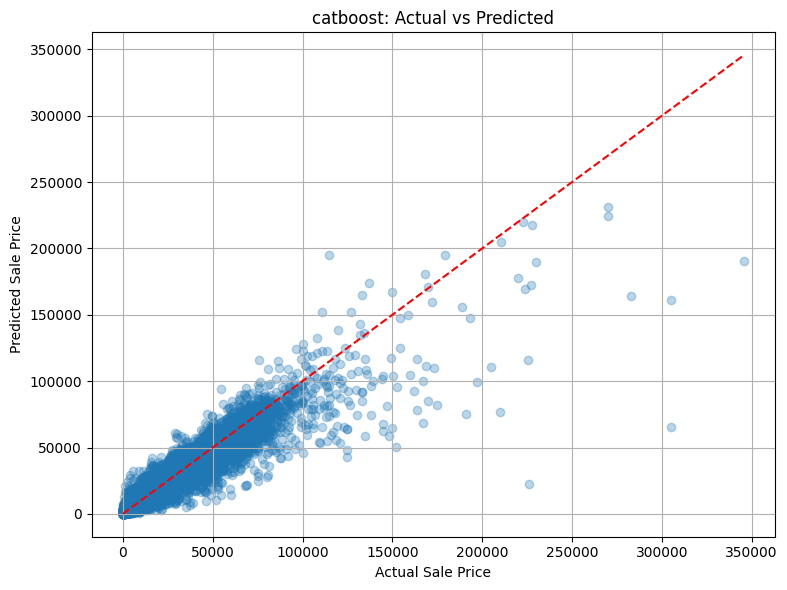

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, catboost_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('catboost: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

CatBoost Native Handling

In [ ]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
# categorical_feats = list(pd.Index(categorical_feats).unique())
# numeric_feats     = list(pd.Index(numeric_feats).unique())
# all_feats         = categorical_feats + numeric_feats  # order matters for indices

In [ ]:
# X_train_all    = X_train[all_feats].copy()
# X_test_all     = X_test[all_feats].copy()
# X_external_all = X_external[all_feats].copy()

In [ ]:
# # 2) Fill/convert categorical columns on ALL splits
# def prep_cats(df, cat_cols):
#     # Fill NaN, then cast to string/object (CatBoost wants strings/ints, not floats/NaN)
#     df[cat_cols] = df[cat_cols].fillna('Unknown').astype(str)
#     return df

# X_train_all    = prep_cats(X_train_all,    categorical_feats)
# X_test_all     = prep_cats(X_test_all,     categorical_feats)
# X_external_all = prep_cats(X_external_all, categorical_feats)

In [ ]:
# # 3) Cat feature indices must match the columns you pass into Pool
# cat_feature_indices = [all_feats.index(c) for c in categorical_feats]

# # 4) Train on log-target and predict
# y_train_log = np.log1p(y_train)

# train_pool = Pool(X_train_all, y_train_log, cat_features=cat_feature_indices)
# test_pool  = Pool(X_test_all,  cat_features=cat_feature_indices)
# ext_pool   = Pool(X_external_all, cat_features=cat_feature_indices)

In [ ]:
# cat_model = CatBoostRegressor(
#     iterations= 1758,
#     learning_rate= 0.093656,
#     depth= int(7.0),
#     rsm= 0.84944,
#     l2_leaf_reg= 4.0704,
#     random_strength = 0.20175,
#     min_data_in_leaf = 3823,
#     subsample = 0.93804,
#     bootstrap_type = 'Bernoulli',
#     loss_function='RMSE',
#     verbose=0,
#     random_state=42,
# )

# cat_model.fit(train_pool)

In [ ]:
# cat_log_preds          = cat_model.predict(test_pool)
# cat_preds              = np.expm1(cat_log_preds)

# cat_log_preds_external = cat_model.predict(ext_pool)
# cat_preds_external     = np.expm1(cat_log_preds_external)

In [ ]:
# cat_r2 = r2_score(y_test, cat_preds)
# cat_mae = mean_absolute_error(y_test, cat_preds)
# cat_mse = mean_squared_error(y_test, cat_preds)
# cat_rmse = np.sqrt(cat_mse)
# cat_mape = mean_absolute_percentage_error(y_test, cat_preds)

# # Display results
# print("📊 catboost Regression Evaluation Metrics")
# print(f"R² Score  : {cat_r2:.4f}")
# print(f"MAE       : {cat_mae:.2f}")
# print(f"MSE       : {cat_mse:.2f}")
# print(f"RMSE      : {cat_rmse:.2f}")
# print(f"MAPE      : {cat_mape:.2%}")

In [ ]:
# plt.figure(figsize=(8,6))
# plt.scatter(y_test, cat_preds, alpha=0.3)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
# plt.xlabel('Actual Sale Price')
# plt.ylabel('Predicted Sale Price')
# plt.title('catboost: Actual vs Predicted')
# plt.grid(True)
# plt.tight_layout()
# plt.show()

Model Combination

In [ ]:
import numpy as np
import pandas as pd

# Base models
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

from lightgbm import LGBMRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
from sklearn.model_selection import cross_val_score

from sklearn.isotonic import IsotonicRegression
from scipy.optimize import nnls

import optuna
from optuna.samplers import TPESampler

In [ ]:
# 0) SETTINGS
# --------------------------------
SEED = 42
RUN_LGBM_TUNING = True   # <<< set False if you just want default LGBM params
LGBM_N_TRIALS = 30       # Optuna trials for LightGBM
LGBM_SUB_FRAC = 0.20     # fraction of train data to use for LGBM tuning if huge

In [ ]:
# 1) LOG-TARGET WRAPPER
# --------------------------------
from sklearn.base import BaseEstimator, RegressorMixin, clone

class LogTargetRegressor(BaseEstimator, RegressorMixin):
    """
    Wraps a regressor so it fits on log1p(y) and predicts on original scale via expm1.
    """
    def __init__(self, base_estimator):
        self.base_estimator = base_estimator

    def fit(self, X, y):
        self.est_ = clone(self.base_estimator)
        y_log = np.log1p(np.asarray(y, dtype=float))
        self.est_.fit(X, y_log)
        return self

    def predict(self, X):
        y_log_pred = self.est_.predict(X)
        return np.expm1(y_log_pred)

def with_log_target(est):
    return LogTargetRegressor(est)

In [ ]:
# 2) YOUR TUNED BASE MODELS
# --------------------------------
catboost_model = CatBoostRegressor(
    iterations= 1793,
    learning_rate= 0.09912556385159192,
    depth= int(9.0),
    rsm= 0.9496437290782105,
    l2_leaf_reg= 5.263059838941717,
    random_strength = 0.584956977885945,
    min_data_in_leaf = 4071,
    subsample = 0.8892185553646252,
    bootstrap_type = 'Bernoulli',
    loss_function='RMSE',                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     
    verbose=0,
    random_state=42,
)

xgb_model = XGBRegressor(
    tree_method = 'hist',
    device = 'cpu',
    max_leaves = 606,
    max_bin = 354,
    learning_rate=0.033461,
    subsample=0.89539,
    colsample_bytree=0.65389,
    colsample_bynode = 0.79437,
    gamma=0.057052,
    min_child_weight=29,
    reg_alpha=0.00050038,
    reg_lambda=0.31906,
    # keep the rest as before:
    grow_policy='lossguide',
    objective='reg:squarederror',
    eval_metric='rmse',
    n_estimators=7138,
)

In [ ]:
# 2) DEFINE STACKED MODEL (CatBoost + XGB + Ridge meta)
# ==================================================

meta = make_pipeline(
    StandardScaler(with_mean=False),
    Ridge(alpha=1.0, random_state=42)
)

stack = StackingRegressor(
    estimators=[('cat', catboost_model), ('xgb', xgb_model)],
    final_estimator=meta,
    passthrough=True,   # we might tune this later
    cv=5,
    n_jobs=1            # keep this 1 to avoid weirdness on Windows
)

stacking_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('stack',   stack),
])

stack_log = with_log_target(stacking_pipeline)

In [ ]:
# 3) STACKING REGRESSOR (LOG TARGET)
# --------------------------------
meta = make_pipeline(
    StandardScaler(with_mean=False),
    Ridge(alpha=82.53877684201471, random_state=SEED)
)

stack = StackingRegressor(
    estimators=[('cat', catboost_model), ('xgb', xgb_model)],
    final_estimator=meta,
    passthrough=False,            # keep raw preprocessed features at meta layer
    cv=5,
    n_jobs=1                     # keep single-threaded inside stack to avoid OS weirdness
)

# preprocessor must be defined earlier by you:
#   - e.g. ColumnTransformer([...]) handling cat/num
#   - we assume it exists: preprocessor

stacking_pipeline = Pipeline([
    ('preproc', preprocessor),
    ('stack',   stack),
])

# Sometimes StackingRegressor exposes n_jobs, make sure it's safe (no multiprocessing issues)
try:
    stacking_pipeline.named_steps['stack'].set_params(n_jobs=1)
except Exception:
    pass

In [ ]:
from sklearn.compose import TransformedTargetRegressor
import numpy as np

stack_log_model = TransformedTargetRegressor(
    regressor=stacking_pipeline,  # can be a Pipeline, including preprocessor + StackingRegressor
    func=np.log1p,
    inverse_func=np.expm1
)

In [ ]:
# from sklearn.model_selection import TimeSeriesSplit, cross_val_score
# from sklearn.pipeline import Pipeline
# from lightgbm import LGBMRegressor
# import optuna
# from optuna.samplers import TPESampler
# import numpy as np

# def tune_lgbm_with_optuna(X_train, y_train):
#     """
#     Tune LGBMRegressor on raw target via Optuna (3-fold CV),
#     using preprocessor inside a Pipeline.
#     """
#     # Optional subsampling for speed if dataset is large
#     if len(X_train) > 300_000:
#         rng = np.random.RandomState(SEED)
#         idx = rng.choice(
#             np.arange(len(X_train)),
#             size=int(len(X_train) * LGBM_SUB_FRAC),
#             replace=False
#         )
#         X_tune = X_train.iloc[idx]
#         y_tune = y_train.iloc[idx]
#     else:
#         X_tune, y_tune = X_train, y_train

#     def objective(trial):
#         params = dict(
#             objective='huber',
#             n_estimators=trial.suggest_int("n_estimators", 800, 4000),
#             learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#             num_leaves=trial.suggest_int("num_leaves", 31, 255),
#             min_child_samples=trial.suggest_int("min_child_samples", 10, 300),
#             subsample=trial.suggest_float("subsample", 0.6, 1.0),
#             colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
#             reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
#             reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
#             random_state=SEED,
#             n_jobs=-1,
#             max_depth=trial.suggest_int("max_depth", -1, 12),  # -1 = no limit
#             verbose=-1,  # <--- add this
#         )

#         model = Pipeline([
#             ('preproc', preprocessor),
#             ('lgb', LGBMRegressor(**params))
#         ])

#         tscv = TimeSeriesSplit(n_splits=3)
#         scores = cross_val_score(
#             model, X_tune, y_tune,
#             cv=tscv,
#             scoring="neg_root_mean_squared_error",
#             n_jobs=1  # pipeline isn't always safe with parallel CV
#         )
#         # Minimize RMSE
#         return -scores.mean()

#     sampler = TPESampler(seed=SEED, multivariate=True, group=True)
#     study = optuna.create_study(direction="minimize", sampler=sampler)
#     study.optimize(objective, n_trials=50, show_progress_bar=True)

#     print("\n=== LIGHTGBM TUNING DONE ===")
#     print(f"Best LGBM CV RMSE: {study.best_value:.4f}")
#     print("Best LGBM params:", study.best_params)

#     return study.best_params

# best_params = tune_lgbm_with_optuna(X_train, y_train)
# print(best_params)

In [ ]:
# if RUN_LGBM_TUNING:
#     best_lgbm_params = tune_lgbm_with_optuna(X_train, y_train)
# else:
    # Reasonable default if you skip tuning
best_lgbm_params = dict(
    objective='huber',
    n_estimators=3906,
    learning_rate=0.19340446003251485,
    num_leaves=56,
    subsample=0.6359758984756145,
    colsample_bytree=0.7664528325730766,
    min_child_samples=10,
    reg_lambda=3.7462977578222008,
    reg_alpha=0.8404814145609042,
    random_state=SEED,
    n_jobs=-1,
    max_depth = 10
)
# Raw-target LightGBM model with tuned params
raw_model = Pipeline([
    ('preproc', preprocessor),
    ('lgb', LGBMRegressor(**best_lgbm_params))
])

In [ ]:
# 5) FIT STACK (LOG-TARGET) + RAW LGBM
# --------------------------------
print("\nFitting log-target stack...")
stack_log_model.fit(X_train, y_train)

print("Fitting tuned raw LightGBM...")
raw_model.fit(X_train, y_train)


Fitting log-target stack...
Fitting tuned raw LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.386035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3393
[LightGBM] [Info] Number of data points in the train set: 4268893, number of used features: 417
[LightGBM] [Info] Start training from score 9450.281460


Pipeline(steps=[('preproc',
                 ColumnTransformer(sparse_threshold=1.0,
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['VRMILEAGE', 'Vehicle_year',
                                                   'Vehicle_cylinders',
                                                   'Vehicle_doors',
                                                   'Vehicle_engine',
                                                   'Vehicle_condition_overall',
                                                   'EngineHP', 'BasePrice',
                                                   'SALEDATE_WeekofYearNumber',
                                                   'SALEDATE_MonthofYearNumber',
                                                   'SALEDATE_Q...
                                                   'MarketSegment', 'Make',
                                                   'VRLIGHTS',
                                                   'Misc_SalesChannel'])])),
                ('lgb',
                 LGBMRegressor(colsample_bytree=0.7664528325730766,
                               learning_rate=0.19340446003251485, max_depth=10,
                               min_child_samples=10, n_estimators=3906,
                               n_jobs=-1, num_leaves=56, objective='huber',
                               random_state=42, reg_alpha=0.8404814145609042,
                               reg_lambda=3.7462977578222008,
                               subsample=0.6359758984756145))])

In [ ]:
# 6) VALIDATION BLEND & CALIBRATION (on X_test / y_test)
# --------------------------------
X_valid, y_valid = X_test, y_test

# Predictions on validation
p_stack_valid = stack_log_model.predict(X_valid)   # already on original scale
p_raw_valid   = raw_model.predict(X_valid)         # raw-price scale

# Convex blend via non-negative least squares
P_valid = np.column_stack([p_stack_valid, p_raw_valid])
w, _ = nnls(P_valid, y_valid.to_numpy().ravel())
if w.sum() > 0:
    w = w / w.sum()
else:
    w = np.array([1.0, 0.0])   # fallback: all weight on stack

print(f"\nBlend weights -> stack_log: {w[0]:.3f} | raw_LGBM: {w[1]:.3f}")

p_blend_valid = P_valid @ w

# Isotonic calibration
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(p_blend_valid, y_valid.to_numpy().ravel())
p_blend_cal_valid = iso.transform(p_blend_valid)


Blend weights -> stack_log: 0.989 | raw_LGBM: 0.011


In [ ]:
# 7) METRIC REPORTING (VALIDATION)
# --------------------------------
def rmse(y_true, y_hat):
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

def report(name, y_true, y_hat):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_hat  = np.asarray(y_hat,  dtype=float).ravel()
    print(
        f"{name:22s}  R2={r2_score(y_true, y_hat):.4f}  "
        f"MAE={mean_absolute_error(y_true, y_hat):,.0f}  "
        f"RMSE={rmse(y_true, y_hat):,.0f}  "
        f"MAPE={mean_absolute_percentage_error(y_true, y_hat):.2%}"
    )

print("\n=== VALIDATION (TEST SET) METRICS ===")
report("Stack (log)        ", y_valid, p_stack_valid)
report("LGBM raw           ", y_valid, p_raw_valid)
report("Blend              ", y_valid, p_blend_valid)
report("Blend + Isotonic   ", y_valid, p_blend_cal_valid)


=== VALIDATION (TEST SET) METRICS ===
Stack (log)             R2=0.9435  MAE=1,509  RMSE=2,750  MAPE=27.98%
LGBM raw                R2=0.0567  MAE=7,513  RMSE=11,235  MAPE=252.05%
Blend                   R2=0.9435  MAE=1,504  RMSE=2,748  MAPE=29.03%
Blend + Isotonic        R2=0.9455  MAE=1,497  RMSE=2,701  MAPE=29.11%


In [ ]:
# 8) FINAL PREDICTIONS (TEST + EXTERNAL)
# --------------------------------
# Test set (same as validation here)
y_pred = p_blend_cal_valid  # <<< final calibrated blend on TEST
# External predictions
p_stack_ext = stack_log_model.predict(X_external)
p_raw_ext   = raw_model.predict(X_external)
P_ext       = np.column_stack([p_stack_ext, p_raw_ext])
p_blend_ext = P_ext @ w
p_blend_cal_ext = iso.transform(p_blend_ext)

y_pred_external = p_blend_cal_ext  # <<< final calibrated blend on EXTERNAL

print("\nShapes:")
print("  y_pred          :", y_pred.shape)
print("  y_pred_external :", y_pred_external.shape)


Shapes:
  y_pred          : (240652,)
  y_pred_external : (30978,)


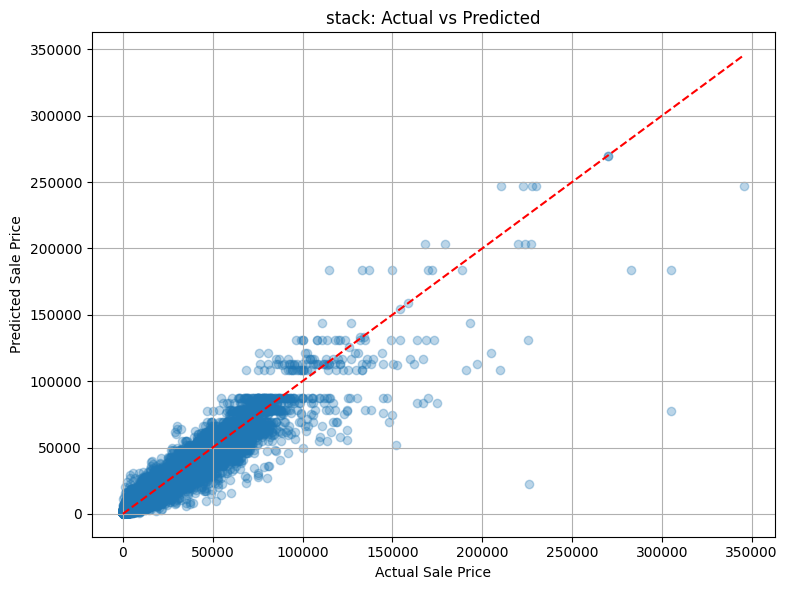

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('stack: Actual vs Predicted')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from scipy.optimize import nnls

# ============================================================
# CONFIG
# ============================================================
TARGET = "VRSALEAMT"
DATE_COL = "sale_date"

BUNDLE_PATH = "stack_lgbm_iso_bundle.joblib"
SCHEMA_VERSION = 2

TE_SMOOTHING = 50.0
TE_MIN_COUNT = 5          # prune ultra-rare categories (reduces noise + bundle size)
MISSING_TOKEN = "__MISSING__"

ISO_SAMPLE_MAX = 200_000  # fit iso on a sample for speed (still plenty at your scale)
RANDOM_SEED = 42

# ============================================================
# 0) SAFETY: de-dup lists (you said these lists already exist)
# ============================================================
numeric_feats      = list(pd.Index(numeric_feats).unique())      # includes te__*
categorical_feats  = list(pd.Index(categorical_feats).unique())  # low-card only (exclude high_card)
high_card          = list(pd.Index(high_card).unique())

te_cols = [f"te__{c}" for c in high_card]
missing_te_in_numeric = [c for c in te_cols if c not in numeric_feats]
if missing_te_in_numeric:
    raise ValueError(f"numeric_feats missing TE columns: {missing_te_in_numeric}")

numeric_feats_raw = [c for c in numeric_feats if not c.startswith("te__")]
numeric_feats_raw = list(pd.Index(numeric_feats_raw).unique())

# ============================================================
# 1) VALIDATE + CLEAN: sale_date + target
# ============================================================
assert DATE_COL in cars.columns, f"{DATE_COL} missing—did you run clean_and_fix_temporal()?"
if not np.issubdtype(cars[DATE_COL].dtype, np.datetime64):
    cars = cars.copy()
    cars[DATE_COL] = pd.to_datetime(cars[DATE_COL], errors="coerce")

cars = cars.dropna(subset=[DATE_COL]).sort_values(DATE_COL)

cars = cars.copy()
cars[TARGET] = pd.to_numeric(cars[TARGET], errors="coerce")
cars = cars.dropna(subset=[TARGET])
# Optional: if 0 / negative sale amounts are invalid in your business logic, keep this:
cars = cars[cars[TARGET] > 0]

# ============================================================
# 2) TIME SPLIT: train / valid / test (prevents calibration leakage)
# ============================================================
q90 = cars[DATE_COL].quantile(0.90)
q95 = cars[DATE_COL].quantile(0.95)

train_mask = cars[DATE_COL] < q90
valid_mask = (cars[DATE_COL] >= q90) & (cars[DATE_COL] < q95)
test_mask  = cars[DATE_COL] >= q95

print("Train range:", cars.loc[train_mask, DATE_COL].min(), "→", cars.loc[train_mask, DATE_COL].max())
print("Valid range:", cars.loc[valid_mask, DATE_COL].min(), "→", cars.loc[valid_mask, DATE_COL].max())
print("Test  range:", cars.loc[test_mask,  DATE_COL].min(), "→", cars.loc[test_mask,  DATE_COL].max())
print("Sizes:", int(train_mask.sum()), int(valid_mask.sum()), int(test_mask.sum()))

# ============================================================
# 3) TARGET ENCODING (TE): fit on train only; apply everywhere
# ============================================================
def fit_te_maps(
    X_train_raw: pd.DataFrame,
    y_train: pd.Series,
    high_card: list,
    smoothing: float = 50.0,
    min_count: int = 1,
    missing_token: str = "__MISSING__",
) -> dict:
    te_maps = {}
    y_train = pd.to_numeric(y_train, errors="coerce").astype("float64")
    global_mean = float(np.nanmean(y_train))

    for col in high_card:
        if col not in X_train_raw.columns:
            te_maps[col] = {"global_mean": global_mean, "mapping": {}}
            continue

        tmp = pd.DataFrame({"col": X_train_raw[col].astype("object"), "y": y_train})
        tmp["col"] = tmp["col"].fillna(missing_token)

        stats = tmp.groupby("col")["y"].agg(["count", "mean"])
        # prune ultra-rare categories (less noise + smaller bundle)
        if min_count > 1:
            stats = stats[stats["count"] >= min_count]

        te = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)
        te_maps[col] = {"global_mean": global_mean, "mapping": te.to_dict()}

    return te_maps

def apply_te_maps(
    df: pd.DataFrame,
    te_maps: dict,
    high_card: list,
    missing_token: str = "__MISSING__",
) -> pd.DataFrame:
    df = df.copy()
    for col in high_card:
        g = float(te_maps[col]["global_mean"])
        m = te_maps[col]["mapping"]
        out_col = f"te__{col}"

        if col not in df.columns:
            df[out_col] = g
        else:
            s = df[col].astype("object").fillna(missing_token)
            df[out_col] = s.map(m).fillna(g)

        df[out_col] = pd.to_numeric(df[out_col], errors="coerce").fillna(g).astype("float32")
    return df

def make_features(
    df_raw: pd.DataFrame,
    te_maps: dict,
    high_card: list,
    numeric_feats: list,
    categorical_feats: list,
) -> pd.DataFrame:
    tmp = apply_te_maps(df_raw, te_maps, high_card, missing_token=MISSING_TOKEN)

    needed = list(pd.Index(numeric_feats + categorical_feats).unique())
    missing = [c for c in needed if c not in tmp.columns]
    if missing:
        raise KeyError(f"make_features missing columns: {missing}")

    X = tmp[needed].copy()

    for c in numeric_feats:
        X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")

    for c in categorical_feats:
        X[c] = X[c].astype("object")

    return X

# build raw frames (must include high_card originals so TE can be applied)
raw_cols_needed = list(pd.Index(numeric_feats_raw + categorical_feats + high_card).unique())

X_train_raw = cars.loc[train_mask, raw_cols_needed].copy()
y_train_raw = cars.loc[train_mask, TARGET].copy()

X_valid_raw = cars.loc[valid_mask, raw_cols_needed].copy()
y_valid_raw = cars.loc[valid_mask, TARGET].copy()

X_test_raw  = cars.loc[test_mask,  raw_cols_needed].copy()
y_test_raw  = cars.loc[test_mask,  TARGET].copy()

# fit TE on train only
te_maps = fit_te_maps(
    X_train_raw,
    y_train_raw,
    high_card=high_card,
    smoothing=TE_SMOOTHING,
    min_count=TE_MIN_COUNT,
    missing_token=MISSING_TOKEN,
)

X_train_for_model = make_features(X_train_raw, te_maps, high_card, numeric_feats, categorical_feats)
X_valid_for_model = make_features(X_valid_raw, te_maps, high_card, numeric_feats, categorical_feats)
X_test_for_model  = make_features(X_test_raw,  te_maps, high_card, numeric_feats, categorical_feats)

# index alignment guards
assert X_train_for_model.index.equals(y_train_raw.index)
assert X_valid_for_model.index.equals(y_valid_raw.index)
assert X_test_for_model.index.equals(y_test_raw.index)

# ============================================================
# 4) FIT THE TWO PRODUCTION MODELS
#   These must already exist in your notebook exactly:
stack_log_model = with_log_target(stacking_pipeline)
raw_model = Pipeline([('preproc', preprocessor), ('lgb', LGBMRegressor(**best_lgbm_params))])
# ============================================================
stack_log_model.fit(X_train_for_model, y_train_raw)
raw_model.fit(X_train_for_model, y_train_raw)

# ============================================================
# 5) FIT BLEND WEIGHTS + ISOTONIC ON VALID ONLY
# ============================================================
p_stack_valid = stack_log_model.predict(X_valid_for_model)
p_raw_valid   = raw_model.predict(X_valid_for_model)

P_valid = np.column_stack([p_stack_valid, p_raw_valid]).astype("float64")
y_valid = y_valid_raw.to_numpy(dtype="float64").ravel()

w, _ = nnls(P_valid, y_valid)
w = w / w.sum() if w.sum() > 0 else np.array([1.0, 0.0], dtype="float64")

p_blend_valid = (P_valid @ w).astype("float64")

iso = IsotonicRegression(out_of_bounds="clip")
# fit isotonic on a sample for speed/stability (still large)
n = len(p_blend_valid)
rs = np.random.RandomState(RANDOM_SEED)
if n > ISO_SAMPLE_MAX:
    idx = rs.choice(n, size=ISO_SAMPLE_MAX, replace=False)
    iso.fit(p_blend_valid[idx], y_valid[idx])
else:
    iso.fit(p_blend_valid, y_valid)

# ============================================================
# 6) EVALUATE ON TEST (UNTOUCHED) — OPTIONAL BUT RECOMMENDED
# ============================================================
def predict_bundle_internal(X_for_model: pd.DataFrame) -> np.ndarray:
    p1 = stack_log_model.predict(X_for_model)
    p2 = raw_model.predict(X_for_model)
    p  = np.column_stack([p1, p2]).astype("float64") @ w
    return iso.predict(p)

p_test = predict_bundle_internal(X_test_for_model)
y_test = y_test_raw.to_numpy(dtype="float64")

mae  = float(np.mean(np.abs(p_test - y_test)))
rmse = float(np.sqrt(np.mean((p_test - y_test) ** 2)))
mape = float(np.mean(np.abs((p_test - y_test) / np.maximum(y_test, 1.0))))  # avoid div-by-0
print(f"TEST  MAE={mae:,.0f}  RMSE={rmse:,.0f}  MAPE={mape*100:,.2f}%")
print("Blend weights:", w)

# ============================================================
# 7) SAVE LEAN BUNDLE + PREDICT HELPER
# ============================================================
def predict_from_bundle(df_raw: pd.DataFrame, bundle: dict) -> np.ndarray:
    # schema check
    missing = [c for c in bundle["raw_cols_needed"] if c not in df_raw.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    X = make_features(
        df_raw[bundle["raw_cols_needed"]],
        bundle["te_maps"],
        bundle["high_card"],
        bundle["numeric_feats"],
        bundle["categorical_feats"],
    )

    p1 = bundle["stack_model"].predict(X)
    p2 = bundle["lgbm_model"].predict(X)
    p  = (np.column_stack([p1, p2]).astype("float64") @ bundle["blend_w"]).astype("float64")
    return bundle["iso"].predict(p)

bundle = {
    "target": TARGET,
    "date_col": DATE_COL,
    "schema_version": SCHEMA_VERSION,

    "raw_cols_needed": raw_cols_needed,
    "high_card": high_card,
    "numeric_feats": numeric_feats,
    "categorical_feats": categorical_feats,

    "te_smoothing": TE_SMOOTHING,
    "te_min_count": TE_MIN_COUNT,
    "missing_token": MISSING_TOKEN,
    "te_maps": te_maps,

    "stack_model": stack_log_model,
    "lgbm_model": raw_model,
    "blend_w": w.astype("float64"),
    "iso": iso,

    "split_info": {
        "train_rows": int(train_mask.sum()),
        "valid_rows": int(valid_mask.sum()),
        "test_rows":  int(test_mask.sum()),
        "train_start": str(cars.loc[train_mask, DATE_COL].min()),
        "train_end":   str(cars.loc[train_mask, DATE_COL].max()),
        "valid_start": str(cars.loc[valid_mask, DATE_COL].min()),
        "valid_end":   str(cars.loc[valid_mask, DATE_COL].max()),
        "test_start":  str(cars.loc[test_mask,  DATE_COL].min()),
        "test_end":    str(cars.loc[test_mask,  DATE_COL].max()),
    },
    "test_metrics": {"mae": mae, "rmse": rmse, "mape": mape},
}

joblib.dump(bundle, BUNDLE_PATH, compress=3)
print(f"Saved: {BUNDLE_PATH}")

Train range: 2019-01-02 00:00:00 → 2025-07-28 00:00:00
Valid range: 2025-07-29 00:00:00 → 2025-11-12 00:00:00
Test  range: 2025-11-13 00:00:00 → 2026-03-13 00:00:00
Sizes: 4268893 236280 240652
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.343293 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3394
[LightGBM] [Info] Number of data points in the train set: 4268893, number of used features: 419
[LightGBM] [Info] Start training from score 9450.281460
TEST  MAE=1,506  RMSE=2,725  MAPE=30.52%
Blend weights: [0.95829368 0.04170632]
Saved: stack_lgbm_iso_bundle.joblib


In [ ]:
# 9) OPTIONAL: LIGHT OPTUNA TUNING OF META (Ridge alpha + passthrough)
# ==================================================

RUN_OPTUNA = False   # flip to True if you want to run this

if RUN_OPTUNA:
    # Use a smaller subset for speed, if dataset is huge
    SUB_FRAC = 0.25
    if len(X_train) > 200_000:
        sub_idx = np.random.RandomState(42).choice(
            np.arange(len(X_train)), size=int(len(X_train)*SUB_FRAC), replace=False
        )
        X_tune = X_train.iloc[sub_idx]
        y_tune = y_train.iloc[sub_idx]
    else:
        X_tune, y_tune = X_train, y_train

    def optuna_objective(trial):
        alpha = trial.suggest_float("alpha", 1e-3, 1e2, log=True)
        passthrough = trial.suggest_categorical("passthrough", [True, False])

        meta_tuned = make_pipeline(
            StandardScaler(with_mean=False),
            Ridge(alpha=alpha, random_state=42)
        )

        stack_tuned = StackingRegressor(
            estimators=[('cat', catboost_model), ('xgb', xgb_model)],
            final_estimator=meta_tuned,
            passthrough=passthrough,
            cv=3,
            n_jobs=1
        )

        pipe_tuned = Pipeline([
            ('preproc', preprocessor),
            ('stack', stack_tuned),
        ])

        est = with_log_target(pipe_tuned)

        # 3-fold CV on tuning subset, optimize RMSE
        scores = cross_val_score(
            est, X_tune, y_tune,
            cv=3,
            scoring="neg_root_mean_squared_error",
            n_jobs=1
        )
        
        return -scores.mean()  # minimize RMSE

    sampler = TPESampler(seed=42, multivariate=True, group=True)
    study = optuna.create_study(direction="minimize", sampler=sampler)
    study.optimize(optuna_objective, n_trials=30, show_progress_bar=True)

    print("\n=== OPTUNA META TUNING RESULTS ===")
    print(f"Best CV RMSE: {study.best_value:.4f}")
    print("Best params:", study.best_params)
    # You can then plug study.best_params["alpha"], ["passthrough"] back into the
    # meta and stack definitions above and re-run the fit/blend/calibration steps.


In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)
import numpy as np

def rmse(y_true, y_hat):
    return float(np.sqrt(mean_squared_error(y_true, y_hat)))

def model_metrics(name, y_true, y_hat):
    return {
        "model": name,
        "R2": r2_score(y_true, y_hat),
        "MAE": mean_absolute_error(y_true, y_hat),
        "RMSE": rmse(y_true, y_hat),
        "MAPE": mean_absolute_percentage_error(y_true, y_hat),
    }

rows_test = []
rows_test.append(model_metrics("XGBoost",              y_test, xgb_predictions))
rows_test.append(model_metrics("CatBoost (pipeline)",  y_test, catboost_preds))
# rows_test.append(model_metrics("CatBoost (native)",    y_test, cat_preds))
rows_test.append(model_metrics("Stack + LGBM blend",   y_test, y_pred))

metrics_test_df = pd.DataFrame(rows_test)
print("\n=== TEST SET METRICS (Time-based holdout) ===")
print(metrics_test_df.sort_values("RMSE"))


=== TEST SET METRICS (Time-based holdout) ===
                 model        R2           MAE          RMSE      MAPE
1  CatBoost (pipeline) -0.861202  10648.984667  15781.175206  3.234481
0              XGBoost -0.879249  10665.831630  15857.503005  3.236131
2   Stack + LGBM blend -0.889916  10657.962179  15902.442166  3.239219


Visualize the actual prices and Predicted prices

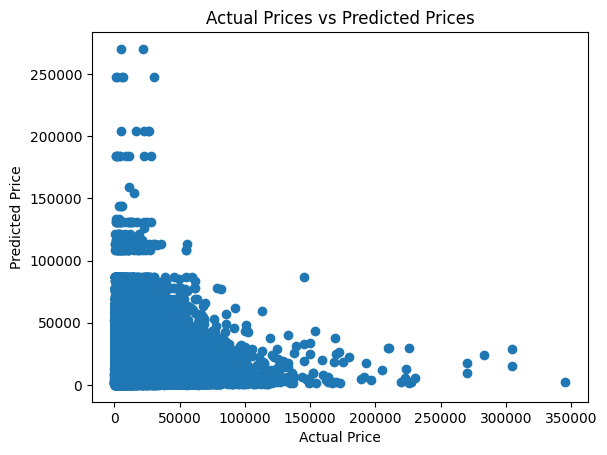

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

Final Model Evaluation

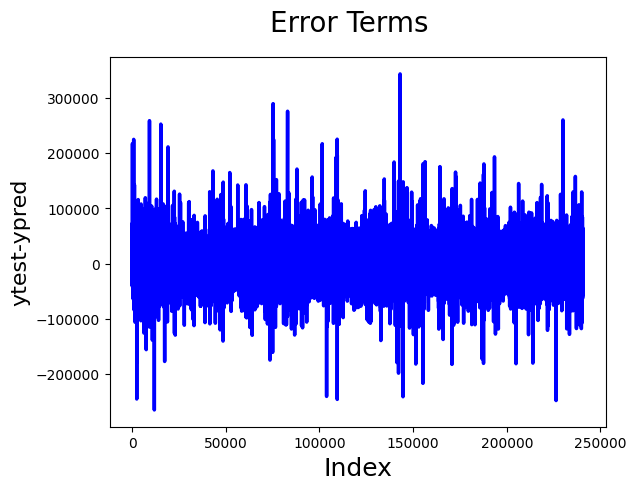

In [ ]:
# Error terms
c = [i for i in range(len(y_pred))]
fig = plt.figure()
plt.plot(c,y_test-y_pred, color="blue", linewidth=2.5, linestyle="-")
fig.suptitle('Error Terms', fontsize=20)              # Plot heading 
plt.xlabel('Index', fontsize=18)                      # X-label
plt.ylabel('ytest-ypred', fontsize=16)                # Y-label
plt.show()

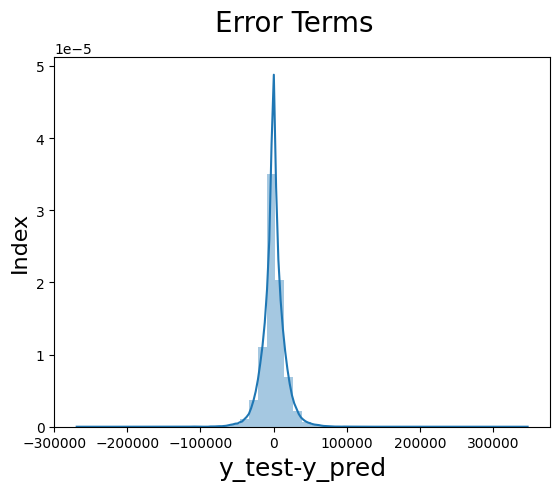

In [ ]:
# Plotting the error terms to understand the distribution.
fig = plt.figure()
sns.distplot((y_test-y_pred),bins=50)
fig.suptitle('Error Terms', fontsize=20)                  # Plot heading 
plt.xlabel('y_test-y_pred', fontsize=18)                  # X-label
plt.ylabel('Index', fontsize=16)                          # Y-label
plt.show()

Export the Predictions

In [ ]:
# 1) Extract the true y values for X_external
y_external = cars_test['VRSALEAMT']

# 2) Compute R² for each model
r2_xgb      = r2_score(y_external, xgb_predictions_external)
r2_catboost = r2_score(y_external, catboost_preds_external)
# r2_Cat_Native = r2_score(y_external, cat_preds_external)
r2_stack    = r2_score(y_external, y_pred_external)

# 3) Print results
print(f"XGBoost external R²:      {r2_xgb:.4f}")
print(f"CatBoost external R²:     {r2_catboost:.4f}")
# print(f"CatBoost Native R²:     {r2_Cat_Native:.4f}")
print(f"Stacked model external R²:{r2_stack:.4f}")

XGBoost external R²:      0.9376
CatBoost external R²:     0.9335
Stacked model external R²:0.9368


In [ ]:
rows_ext = []
rows_ext.append(model_metrics("XGBoost",              y_external, xgb_predictions_external))
rows_ext.append(model_metrics("CatBoost (pipeline)",  y_external, catboost_preds_external))
# rows_ext.append(model_metrics("CatBoost (native)",    y_external, cat_preds_external))
rows_ext.append(model_metrics("Stack + LGBM blend",   y_external, y_pred_external))

metrics_ext_df = pd.DataFrame(rows_ext)
print("\n=== EXTERNAL SET METRICS (True held-out customers) ===")
print(metrics_ext_df.sort_values("RMSE"))


=== EXTERNAL SET METRICS (True held-out customers) ===
                 model        R2          MAE         RMSE      MAPE
0              XGBoost  0.937567  1256.185669  2079.054112  0.364440
2   Stack + LGBM blend  0.936817  1253.099543  2091.505969  0.376088
1  CatBoost (pipeline)  0.933459  1279.819767  2146.373614  0.378696


In [ ]:
# # Create a DataFrame with the original prices and the predicted sales prices
# result_df = pd.DataFrame({
#     'SoldPrice': y_test,  # Original prices from y_test
#     'XGB_Predictions': xgb_predictions,
#     'RF_Predictions': rf_predictions,
#     'Stacked_Predictions': y_pred
# })
1
result_df = pd.DataFrame({
    'XGB_Predictions': xgb_predictions_external,
    'CatBoost_Predictions': catboost_preds_external,
    # 'CatBoost_Native_Predictions': cat_preds_external,
    'Stacked_Predictions': y_pred_external,
})

final_df = pd.concat([cars_test_original.reset_index(drop=True), result_df.reset_index(drop=True)], axis=1)

# Export the DataFrame to a CSV file
final_df.to_excel('AAA Test.xlsx', sheet_name='sheet 1', index=False)

In [34]:
# from sklearn.metrics import (
#     r2_score,
#     mean_absolute_error,
#     mean_squared_error,
#     mean_absolute_percentage_error,
# )
# import numpy as np

# def rmse(y_true, y_hat):
#     return float(np.sqrt(mean_squared_error(y_true, y_hat)))

# def metrics_row(name, y_true, y_hat):
#     return {
#         "model": name,
#         "R2": r2_score(y_true, y_hat),
#         "MAE": mean_absolute_error(y_true, y_hat),
#         "RMSE": rmse(y_true, y_hat),
#         "MAPE": mean_absolute_percentage_error(y_true, y_hat),
#     }

# # --- Baseline 1: Global median ---
# global_median = y_train.median()
# baseline1_pred = np.full_like(y_test, fill_value=global_median, dtype=float)

# # --- Baseline 2: Mean by (Make, Model, Year) ---
# key_cols2 = ["Make", "Model", "Vehicle_year"]
# train_keys2 = cars.loc[train_mask, key_cols2].copy()
# test_keys2  = cars.loc[test_mask,  key_cols2].copy()

# group_mean2 = (
#     pd.concat([train_keys2, y_train.reset_index(drop=True)], axis=1)
#       .groupby(key_cols2)["VRSALEAMT"].mean()
# )

# baseline2_pred = test_keys2.merge(
#     group_mean2.rename("group_mean"),
#     left_on=key_cols2,
#     right_index=True,
#     how="left"
# )["group_mean"].fillna(global_median).to_numpy()

# # --- Baseline 3: Mean by (Make, Model, Year, Trim) ---
# key_cols3 = ["Make", "Model", "Vehicle_year", "Trim"]
# train_keys3 = cars.loc[train_mask, key_cols3].copy()
# test_keys3  = cars.loc[test_mask,  key_cols3].copy()

# group_mean3 = (
#     pd.concat([train_keys3, y_train.reset_index(drop=True)], axis=1)
#       .groupby(key_cols3)["VRSALEAMT"].mean()
# )

# baseline3_pred = test_keys3.merge(
#     group_mean3.rename("group_mean"),
#     left_on=key_cols3,
#     right_index=True,
#     how="left"
# )["group_mean"].fillna(global_median).to_numpy()

# # --- Your existing models on TEST ---
# rows = []
# rows.append(metrics_row("Baseline: global median",       y_test, baseline1_pred))
# rows.append(metrics_row("Baseline: Make-Model-Year",     y_test, baseline2_pred))
# rows.append(metrics_row("Baseline: Make-Model-Year-Trim",y_test, baseline3_pred))

# rows.append(metrics_row("XGBoost tuned",                 y_test, xgb_predictions))
# rows.append(metrics_row("CatBoost pipeline",             y_test, catboost_preds))
# rows.append(metrics_row("CatBoost native",               y_test, cat_preds))
# rows.append(metrics_row("Stack + LGBM + isotonic",       y_test, y_pred))  # your final

# metrics_test_df = pd.DataFrame(rows)
# print("\n=== TEST SET PERFORMANCE COMPARISON ===")
# print(metrics_test_df.sort_values("RMSE"))

In [35]:
# best_baseline_rmse = metrics_test_df[metrics_test_df['model'].str.startswith("Baseline")]["RMSE"].min()
# best_model_rmse    = metrics_test_df.query("model == 'Stack + LGBM + isotonic'")["RMSE"].iloc[0]

# improvement_pct = 100 * (best_baseline_rmse - best_model_rmse) / best_baseline_rmse
# print(f"\nFinal model RMSE improvement over best baseline: {improvement_pct:.1f}%")

In [31]:
cols_sort = ["Make", "Model", "Trim", "Series", "VRLOCATION","VRMILEAGE", "Vehicle_condition_overall"]
cols_show = cols_sort + ["VRSALEAMT"]

cars_sorted = cars.sort_values(cols_sort, ascending=True).reset_index(drop=True)
cars_top = cars_sorted.head(10).copy()

# 1) Make pandas print wide tables without wrapping
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

# 2) Force a single-block text table
print(cars_top[cols_show].to_string(index=False))

                Make Model                   Trim Series      VRLOCATION  VRMILEAGE  Vehicle_condition_overall  VRSALEAMT
A.P.C. MOTOR COMPANY  None                   None   None        LASVEGAS     8336.0                        4.0     4900.0
               ACURA   ADX                    ADX   None  CENTRALHOUSTON     5139.0                        5.0    28250.0
               ACURA   ADX             ADX A-Spec   None AUCTIONINMOTION     3489.0                        NaN    31800.0
               ACURA   ADX ADX AWD A-Spec Advance   None AUCTIONINMOTION      419.0                        NaN    36200.0
               ACURA    CL                    2.3   None          AUSTIN   216014.0                        NaN      600.0
               ACURA    CL                    2.3   None     BADGERSTATE   378779.0                        NaN      225.0
               ACURA    CL                    2.3   None      CHARLESTON   203154.0                        NaN      600.0
               ACURA    

In [ ]:
cars_all = cars.copy()

# Define “near-duplicate” with broader keys + band
cars_all["mileage_band"] = (cars_all["VRMILEAGE"] // 10_000) * 10_000
group_cols = ["Make", "Model", "Vehicle_year", "Trim", "mileage_band","VRLOCATION"]

noise_all = (
    cars_all
    .groupby(group_cols)["VRSALEAMT"]
    .agg(
        count  = "count",
        mean   = "mean",
        std    = "std",
        min    = "min",
        max    = "max",
        spread = lambda s: s.max() - s.min()
    )
    .reset_index()
)

noise_all = noise_all[noise_all["count"] >= 2].dropna(subset=["std"])

print("Groups with ≥2 near-duplicate cars:", len(noise_all))

if not noise_all.empty:
    noise_floor = noise_all["std"].median()
    print("\n=== Noise summary (all cars) ===")
    print("Median within-group price std (≈ noise RMSE):", noise_floor)
    print("Mean within-group price std               :", noise_all["std"].mean())
    print("Median within-group price spread (max-min):", noise_all["spread"].median())
    print("90th percentile std                       :", noise_all["std"].quantile(0.9))

Groups with ≥2 near-duplicate cars: 585431

=== Noise summary (all cars) ===
Median within-group price std (≈ noise RMSE): 1466.0036380127665
Mean within-group price std               : 1992.9750621239416
Median within-group price spread (max-min): 2700.0
90th percentile std                       : 4237.1233503067015
